In [1]:
pip uninstall -y scikit-learn numpy scipy

Found existing installation: scikit-learn 1.2.2
Uninstalling scikit-learn-1.2.2:
  Successfully uninstalled scikit-learn-1.2.2
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.15.3
Uninstalling scipy-1.15.3:
  Successfully uninstalled scipy-1.15.3
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install numpy==1.26.4 scipy==1.11.4 scikit-learn==1.4.2 imbalanced-learn==0.14.0 --no-cache-dir --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 128.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 217.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 257.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 234.5 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 364.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 355.7 MB/s eta 0:00:00
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.6.0
    Uninstalling threadpoolctl-3.6.0:
      Successfully uninstalled threadpoolctl-3.6.0
  Attempting uninstall: joblib
    Found existing installation: joblib 1.5.1
    Uninstalling joblib-1.5.1:
      Successfully uninstalled joblib-1.5.1
  Attempting uninstall: imbalanced-learn
    Found existing installation: imba

In [3]:
import os
import tensorflow as tf

# Enable dynamic GPU memory allocation
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU found and configured for dynamic memory allocation.")
    except Exception as e:
        print(f"Error configuring GPU, defaulting to CPU. Error: {e}")
        os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
else:
    print("No GPU found. Using CPU.")
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

2025-12-25 14:32:21.231113: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766673141.610677      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766673141.723507      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


GPU found and configured for dynamic memory allocation.


In [4]:
import os
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input, Bidirectional, LSTM, GRU, Reshape, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from imblearn.keras import BalancedBatchGenerator

In [5]:
# --- Section 1: Data Loading and Preprocessing ---
import os
import scipy.io
import numpy as np
import gc

base_path = '/kaggle/input/bciaut-p300/data'
all_eeg_data = []
all_eeg_labels = []
subjects = sorted([d for d in os.listdir(base_path) if d.startswith('SBJ')])
print(f"Found {len(subjects)} subjects. Starting data loading...")

for subject_id in subjects:
    subject_path = os.path.join(base_path, subject_id)
    sessions = sorted([d for d in os.listdir(subject_path) if d.startswith('S')])
    for session_id in sessions:
        train_data_path = os.path.join(subject_path, session_id, 'Train', 'trainData.mat')
        train_labels_path = os.path.join(subject_path, session_id, 'Train', 'trainTargets.txt')
        try:
            eeg_data_dict = scipy.io.loadmat(train_data_path)
            eeg_data = eeg_data_dict['trainData']
            if eeg_data.size == 0:
                print(f"Empty data in {train_data_path}, skipping.")
                continue
            eeg_labels = np.loadtxt(train_labels_path)
            all_eeg_data.append(eeg_data)
            all_eeg_labels.append(eeg_labels)
            del eeg_data, eeg_data_dict  # Free memory
            gc.collect()
        except Exception as e:
            print(f"Error loading {session_id}: {e}")
            continue

if all_eeg_data:
    combined_eeg_data = np.concatenate(all_eeg_data, axis=2)
    combined_eeg_labels = np.concatenate(all_eeg_labels)
    print("\nData loading complete!")
    print("Shape of combined EEG data:", combined_eeg_data.shape)
    print("Shape of combined labels:", combined_eeg_labels.shape)
else:
    print("\nNo data was loaded. Please check the file path.")
    raise ValueError("No data loaded, stopping execution.")

Found 15 subjects. Starting data loading...

Data loading complete!
Shape of combined EEG data: (8, 350, 168000)
Shape of combined labels: (168000,)


In [6]:
import numpy as np
import scipy.signal as sg
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE
import gc

In [7]:
SFREQ = 250                     # Hz
WINDOW_START = -200             # in ms (dataset reference only)
CROP_START_MS = 200             # desired window start (200ms)
CROP_END_MS   = 600             # desired window end (600ms)

LOWCUT = 0.1
HIGHCUT = 30.0

In [8]:
# dataset samples: -200 ms → 1200 ms = 1400ms total
# 1 ms = SFREQ / 1000 samples

samples_per_ms = SFREQ / 1000
crop_start_idx = int((CROP_START_MS - WINDOW_START) * samples_per_ms)
crop_end_idx   = int((CROP_END_MS   - WINDOW_START) * samples_per_ms)

print("Cropping indices:", crop_start_idx, crop_end_idx)

Cropping indices: 100 200


In [9]:
def bandpass_filter(X, sfreq=SFREQ, low=LOWCUT, high=HIGHCUT):
    ny = 0.5 * sfreq
    b, a = sg.butter(4, [low/ny, high/ny], btype='band')
    
    Xf = np.zeros_like(X)

    for i in range(X.shape[0]):         # samples
        for ch in range(X.shape[2]):    # channels
            Xf[i,:,ch] = sg.filtfilt(b, a, X[i,:,ch])

    return Xf

In [10]:
def random_bandstop(X, sfreq=SFREQ, width=2.0):
    out = np.zeros_like(X)
    for i in range(X.shape[0]):
        for ch in range(X.shape[2]):
            f0 = np.random.uniform(2, 30-width)
            b,a = sg.iirnotch(f0/(sfreq/2), 30)
            out[i,:,ch] = sg.filtfilt(b,a,X[i,:,ch])
    return out

In [11]:
def fourier_surrogate(signal):
    fft_vals = np.fft.rfft(signal)
    mag = np.abs(fft_vals)
    rand_phase = np.exp(1j * np.random.uniform(0, 2*np.pi, len(fft_vals)))
    surrogate = np.fft.irfft(mag * rand_phase)
    return surrogate

In [12]:
def apply_fourier_surrogate(X):
    out = np.zeros_like(X)
    for i in range(X.shape[0]):
        for ch in range(X.shape[2]):
            out[i,:,ch] = fourier_surrogate(X[i,:,ch])
    return out

In [13]:
def apply_feature_engineering(X):
    print(" → Bandpass 0.1–30 Hz")
    X = bandpass_filter(X)
    return X

In [14]:
X = np.transpose(combined_eeg_data, (2, 1, 0))
y = combined_eeg_labels.astype(int)

print("Raw X:", X.shape)

X = X[:, crop_start_idx : crop_end_idx, :]
print("After cropping:", X.shape)

mean = X.mean(axis=(0,1), keepdims=True)
std  = X.std(axis=(0,1), keepdims=True)
X = (X - mean) / std


Raw X: (168000, 350, 8)
After cropping: (168000, 100, 8)


In [15]:
import numpy as np

# y is already 1D (0 = non-P300, 1 = P300)
y_labels = y.astype(int)

# Indices
p300_idx = np.where(y_labels == 1)[0]
non_p300_idx = np.where(y_labels == 0)[0]

print("Before balancing:")
print("P300:", len(p300_idx))
print("Non-P300:", len(non_p300_idx))

# Downsample non-P300
np.random.seed(42)
non_p300_downsampled = np.random.choice(
    non_p300_idx,
    size=len(p300_idx),
    replace=False
)

# Combine
balanced_idx = np.concatenate([p300_idx, non_p300_downsampled])
np.random.shuffle(balanced_idx)

X_balanced = X[balanced_idx]
y_balanced = y_labels[balanced_idx]

print("After balancing:")
print("Class counts:", np.bincount(y_balanced))

Before balancing:
P300: 21000
Non-P300: 147000
After balancing:
Class counts: [21000 21000]


In [16]:
from tensorflow.keras.utils import to_categorical

y_balanced_cat = to_categorical(y_balanced, num_classes=2)

In [17]:
from sklearn.model_selection import train_test_split

# Train vs temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.30,
    stratify=y_balanced,
    random_state=42
)

# Val vs Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [18]:
def subject_wise_zscore(X):
    # X shape: (trials, time, channels)
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True) + 1e-6
    return (X - mean) / std

X_train = subject_wise_zscore(X_train)
X_val = subject_wise_zscore(X_val)
X_test  = subject_wise_zscore(X_test)

In [19]:
print("\nApplying feature engineering...")
X_train_fe = apply_feature_engineering(X_train)


Applying feature engineering...
 → Bandpass 0.1–30 Hz


In [20]:
X_train_final = X_train_fe[..., np.newaxis]
X_val_final   = X_val[..., np.newaxis]
X_test_final  = X_test[..., np.newaxis]

y_train_cat = to_categorical(y_train)
y_val_cat   = to_categorical(y_val)
y_test_cat  = to_categorical(y_test)

In [21]:
print("Final train:", X_train_final.shape)
print("Final val:",   X_val_final.shape)
print("Final test:",  X_test_final.shape)

Final train: (29400, 100, 8, 1)
Final val: (6300, 100, 8, 1)
Final test: (6300, 100, 8, 1)


In [22]:
num_classes = y_train_cat.shape[1]

In [23]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight = {
    0: class_weights[0],
    1: class_weights[1]
}

print("Class weights:", class_weight)

Class weights: {0: 1.0, 1: 1.0}


In [24]:
def plot_training_history(history, model_name):
    """Plots all available metrics in the training history."""
    available_metrics = list(history.history.keys())
    print(f"Available metrics in history: {available_metrics}")

    plt.figure(figsize=(12, 5))
    # Plot loss
    if 'loss' in available_metrics:
        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='Training Loss')
        if 'val_loss' in available_metrics:
            plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title(f'{model_name} Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
    
    # Plot other metrics
    plt.subplot(1, 2, 2)
    metric_plotted = False
    for metric in available_metrics:
        if metric not in ['loss', 'val_loss']:
            plt.plot(history.history[metric], label=f'Training {metric.capitalize()}')
            val_metric = 'val_' + metric
            if val_metric in available_metrics:
                plt.plot(history.history[val_metric], label=f'Validation {metric.capitalize()}')
            metric_plotted = True

    if metric_plotted:
        plt.title(f'{model_name} Metrics')
        plt.xlabel('Epochs')
        plt.ylabel('Metric Value')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()



# --- Function to plot confusion matrix ---
def plot_confusion_matrix(y_true, y_pred, model_name, labels=['Non-P300', 'P300'], title_suffix=''):
    """
    Generates and displays a confusion matrix plot.
    
    y_true: true labels
    y_pred: predicted labels (can be probabilities or class indices)
    """
    # If y_pred are probabilities, convert to class indices
    if y_pred.ndim > 1 and y_pred.shape[1] > 1:
        y_pred = y_pred.argmax(axis=1)
    
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(f'Confusion Matrix for {model_name}{title_suffix}')
    plt.show()


In [25]:
# --- Function to adjust threshold and evaluate ---
def adjust_threshold_and_evaluate(y_true_int, y_pred_probs, model_name, threshold):
    """
    Adjusts the classification threshold and prints new performance metrics.
    """
    print(f"\n--- Evaluating {model_name} with Threshold: {threshold} ---")
    y_pred_adjusted = (y_pred_probs[:, 1] > threshold).astype(int)
    
    report = classification_report(y_true_int, y_pred_adjusted, target_names=['Non-P300', 'P300'], output_dict=True)
    print(classification_report(y_true_int, y_pred_adjusted, target_names=['Non-P300', 'P300']))
    
    plot_confusion_matrix(y_true_int, y_pred_adjusted, model_name, title_suffix=f' (Threshold: {threshold})')
    
    return report

In [26]:
input_shape = (X_train_final.shape[1:])
print(f"The input_shape is: {input_shape}")

The input_shape is: (100, 8, 1)


In [27]:
input_shape_2d = X_train_final.shape[0:]
print(f"The input_shape_2d for the 2D CNN is: {input_shape_2d}")

The input_shape_2d for the 2D CNN is: (29400, 100, 8, 1)


In [28]:
from sklearn.metrics import f1_score

In [29]:
class P300MacroF1Checkpoint(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val, filepath, threshold=0.3):
        super().__init__()
        self.X_val = X_val
        self.y_val = np.argmax(y_val, axis=1)
        self.filepath = filepath
        self.threshold = threshold
        self.best_f1 = 0.0

    def on_epoch_end(self, epoch, logs=None):
        probs = self.model.predict(self.X_val, verbose=0)[:, 1]
        y_pred = (probs >= self.threshold).astype(int)

        f1_p300 = f1_score(self.y_val, y_pred, pos_label=1, zero_division=0)
        f1_nonp300 = f1_score(self.y_val, y_pred, pos_label=0, zero_division=0)

        f1_macro = 0.5 * (f1_p300 + f1_nonp300)

        if f1_macro > self.best_f1:
            self.best_f1 = f1_macro
            self.model.save(self.filepath, include_optimizer=False)
            print(
                f"  Saved best model — "
                f"F1_macro: {f1_macro:.4f} | "
                f"F1_P300: {f1_p300:.4f} | "
                f"F1_NonP300: {f1_nonp300:.4f}"
            )

In [30]:
# ---- FORCE 1D SHAPE ----
X_train_cnn = np.squeeze(X_train_final, axis=-1)
X_val_cnn   = np.squeeze(X_val_final, axis=-1)
X_test_cnn  = np.squeeze(X_test_final, axis=-1)

print("Train shape:", X_train_cnn.shape)
print("Val shape:  ", X_val_cnn.shape)
print("Test shape: ", X_test_cnn.shape)

Train shape: (29400, 100, 8)
Val shape:   (6300, 100, 8)
Test shape:  (6300, 100, 8)


In [31]:
p300_chkpt = P300MacroF1Checkpoint(
    X_val=X_val_final,
    y_val=y_val_cat,
    filepath="best_cnn_model_p300_f1.h5",
)

In [32]:
input_shape = X_train_cnn.shape[1:]   
num_classes = y_train_cat.shape[1]

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization,
    MaxPooling1D, Flatten, Dense, Dropout
)

cnn_model = Sequential([
    Input(shape=input_shape),

    Conv1D(32, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(64, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.metrics.Recall(class_id=0, name='recall_nonp300'),
            tf.metrics.Precision(class_id=0, name='precision_nonp300')
            ]
)
history = cnn_model.fit(
    X_train_cnn, y_train_cat,
    validation_data=(X_val_cnn, y_val_cat),
    epochs=60,
    batch_size=16,
    callbacks=[p300_chkpt],
    verbose=1
)

I0000 00:00:1766673242.010934      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1766673242.011668      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/60


I0000 00:00:1766673248.367737     117 service.cc:148] XLA service 0x79e8d0012bb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766673248.369400     117 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1766673248.369437     117 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1766673248.890801     117 cuda_dnn.cc:529] Loaded cuDNN version 90300


  53/1838 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - auc: 0.5544 - loss: 1.3543 - precision_nonp300: 0.4825 - precision_p300: 0.5831 - recall_nonp300: 0.4524 - recall_p300: 0.6115  

I0000 00:00:1766673252.568946     117 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1838/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.5888 - loss: 0.8913 - precision_nonp300: 0.5681 - precision_p300: 0.5749 - recall_nonp300: 0.5640 - recall_p300: 0.5790  Saved best model — F1_macro: 0.4529 | F1_P300: 0.6778 | F1_NonP300: 0.2280
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - auc: 0.5888 - loss: 0.8912 - precision_nonp300: 0.5681 - precision_p300: 0.5749 - recall_nonp300: 0.5640 - recall_p300: 0.5790 - val_auc: 0.6886 - val_loss: 0.6355 - val_precision_nonp300: 0.6297 - val_precision_p300: 0.6398 - val_recall_nonp300: 0.6533 - val_recall_p300: 0.6159
Epoch 2/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - auc: 0.6807 - loss: 0.6440 - precision_nonp300: 0.6269 - precision_p300: 0.6424 - recall_nonp300: 0.6627 - recall_p300: 0.6056 - val_auc: 0.7132 - val_loss: 0.6273 - val_precision_nonp300: 0.6338 - val_precision_p300: 0.6724 - val_recall_nonp300: 0.7137 - val_recall_p300: 0.5876
Epoch 3/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - auc: 0.6925 - loss: 0.6364 - preci

In [34]:
probs_val = cnn_model.predict(X_val_final)[:, 1]
y_true = np.argmax(y_val_cat, axis=1)

197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


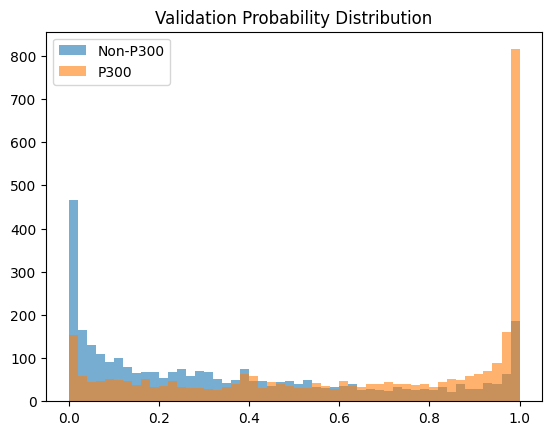

In [35]:
import matplotlib.pyplot as plt

plt.hist(probs_val[y_true == 0], bins=50, alpha=0.6, label="Non-P300")
plt.hist(probs_val[y_true == 1], bins=50, alpha=0.6, label="P300")
plt.legend()
plt.title("Validation Probability Distribution")
plt.show()

In [36]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_true,
    probs_val
)

f1 = 2 * precision * recall / (precision + recall + 1e-8)
best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print(f"Best threshold from validation = {best_threshold:.4f}")


Best threshold from validation = 0.1165


In [37]:
y_test_pred_prob = cnn_model.predict(X_test_final)
y_test_pred = (y_test_pred_prob[:, 1] >= best_threshold).astype(int)

197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


              precision    recall  f1-score   support

    Non-P300       0.68      0.62      0.65      3150
        P300       0.65      0.70      0.67      3150

    accuracy                           0.66      6300
   macro avg       0.66      0.66      0.66      6300
weighted avg       0.66      0.66      0.66      6300



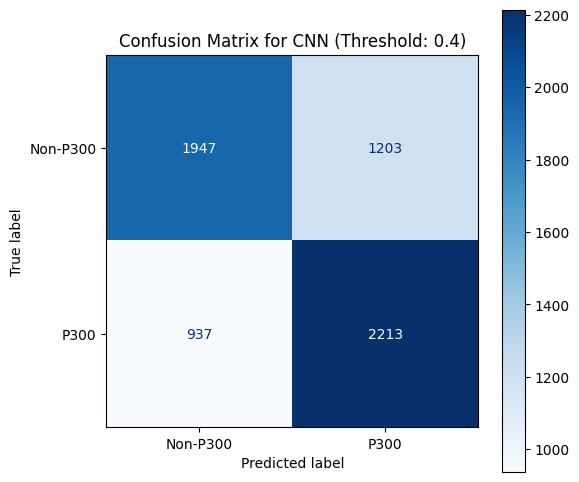

In [38]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_true,
    probs_val
)
f1 = 2 * precision * recall / (precision + recall + 1e-8)
best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]
y_pred = (probs_val >= 0.4).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true, y_pred, target_names=["Non-P300", "P300"]))
plot_confusion_matrix(y_true, y_pred, "CNN", labels=['Non-P300', 'P300'], title_suffix=f' (Threshold: {0.4})')

Available metrics in history: ['auc', 'loss', 'precision_nonp300', 'precision_p300', 'recall_nonp300', 'recall_p300', 'val_auc', 'val_loss', 'val_precision_nonp300', 'val_precision_p300', 'val_recall_nonp300', 'val_recall_p300']


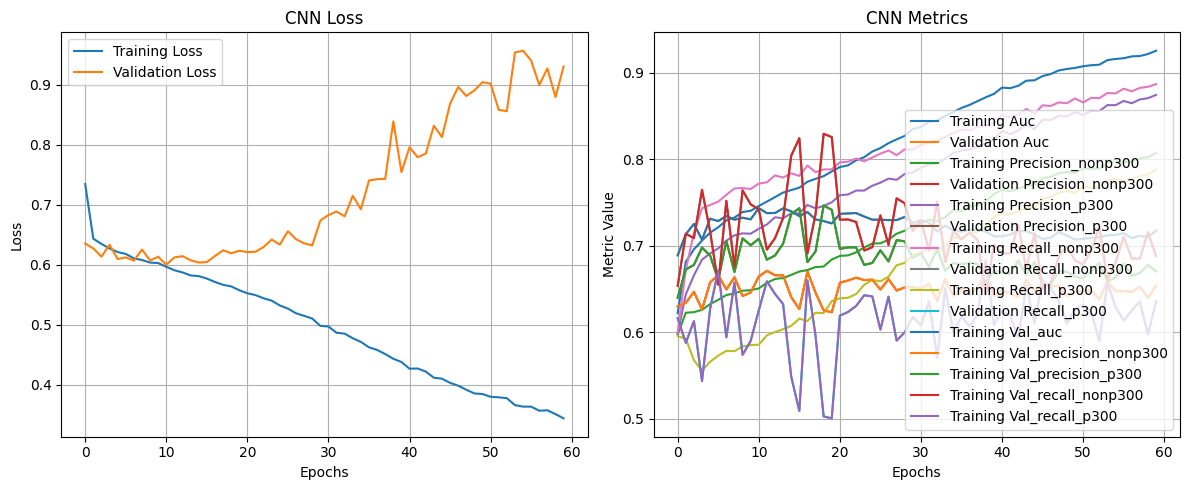

In [39]:
plot_training_history(history, "CNN")

In [40]:
p300_ckpt = P300MacroF1Checkpoint(
    X_val=X_val_final,
    y_val=y_val_cat,
    filepath="best_bilstm_p300.h5",
)

In [41]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense

In [42]:
print("\n--- Training Bi-LSTM Model ---")

input_tensor = Input(shape=input_shape)  # (time, channels)

# CNN front-end (light, EEG-safe)
x = Conv1D(filters=32, kernel_size=5, padding='same', activation='relu')(input_tensor)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.4)(x)

# BiLSTM stack
x = Bidirectional(LSTM(32, return_sequences=True))(x)
x = Dropout(0.4)(x)
x = Bidirectional(LSTM(16))(x)
x = Dropout(0.4)(x)

# Classifier
x = Dense(64, activation='relu')(x)
output_tensor = Dense(num_classes, activation='softmax')(x)

bilstm_model = Model(inputs=input_tensor, outputs=output_tensor)

bilstm_model.compile(
    optimizer=Adam(learning_rate=1e-4, clipvalue=1.0),
    loss='categorical_crossentropy',
    metrics=[tf.metrics.AUC(name='auc'),
        tf.metrics.Recall(class_id=1, name='recall_p300'),
        tf.metrics.Precision(class_id=1, name='precision_p300'),
        tf.metrics.Recall(class_id=0, name='recall_nonp300'),
        tf.metrics.Precision(class_id=0, name='precision_nonp300')]
)

bilstm_model.summary()



--- Training Bi-LSTM Model ---


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 100, 32)        │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 64)         │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,562 (119.38 KB)

 Trainable params: 30,562 (119.38 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
bilstm_history = bilstm_model.fit(
    X_train_final,
    y_train_cat,
    epochs=60,
    batch_size=16,
    validation_data=(X_val_final, y_val_cat),
    callbacks=[p300_ckpt],
    shuffle=True,
    verbose=1
)

Epoch 1/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - auc: 0.5369 - loss: 0.6925 - precision_nonp300: 0.5337 - precision_p300: 0.5286 - recall_nonp300: 0.5461 - recall_p300: 0.5159  Saved best model — F1_macro: 0.3333 | F1_P300: 0.6667 | F1_NonP300: 0.0000
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 45s 19ms/step - auc: 0.5369 - loss: 0.6925 - precision_nonp300: 0.5337 - precision_p300: 0.5286 - recall_nonp300: 0.5461 - recall_p300: 0.5160 - val_auc: 0.5155 - val_loss: 0.6934 - val_precision_nonp300: 0.5121 - val_precision_p300: 0.5166 - val_recall_nonp300: 0.5930 - val_recall_p300: 0.4349
Epoch 2/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 32s 18ms/step - auc: 0.5547 - loss: 0.6890 - precision_nonp300: 0.5417 - precision_p300: 0.5429 - recall_nonp300: 0.5655 - recall_p300: 0.5188 - val_auc: 0.5256 - val_loss: 0.6932 - val_precision_nonp300: 0.5298 - val_precision_p300: 0.5274 - val_recall_nonp300: 0.5079 - val_recall_p300: 0.5492
Epoch 3/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - auc: 0.5751 - los

In [44]:
# =========================
# Predict probabilities
# =========================

# Validation set (for threshold tuning)
probs_val = bilstm_model.predict(X_val_final, verbose=0)[:, 1]
y_val_true = np.argmax(y_val_cat, axis=1)

# Test set (for final evaluation ONLY)
probs_test = bilstm_model.predict(X_test_final, verbose=0)[:, 1]
y_test_true = y_test.astype(int)

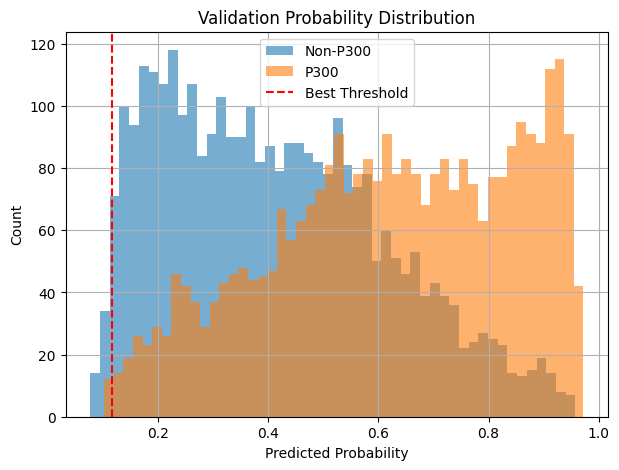

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(probs_val[y_val_true == 0], bins=50, alpha=0.6, label="Non-P300")
plt.hist(probs_val[y_val_true == 1], bins=50, alpha=0.6, label="P300")
plt.axvline(best_threshold, color='red', linestyle='--', label='Best Threshold')
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Validation Probability Distribution")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_val_true,
    probs_val
)

# thresholds has length = len(precision) - 1
precision = precision[:-1]
recall = recall[:-1]

f1 = 2 * precision * recall / (precision + recall + 1e-8)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (VAL): {best_threshold:.4f}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall:    {recall[best_idx]:.4f}")
print(f"F1-score:  {f1[best_idx]:.4f}")

Best Threshold (VAL): 0.3973
Precision: 0.6301
Recall:    0.8216
F1-score:  0.7132



--- FINAL TEST SET PERFORMANCE ---
              precision    recall  f1-score   support

    Non-P300       0.75      0.54      0.63      3150
        P300       0.64      0.82      0.72      3150

    accuracy                           0.68      6300
   macro avg       0.69      0.68      0.67      6300
weighted avg       0.69      0.68      0.67      6300



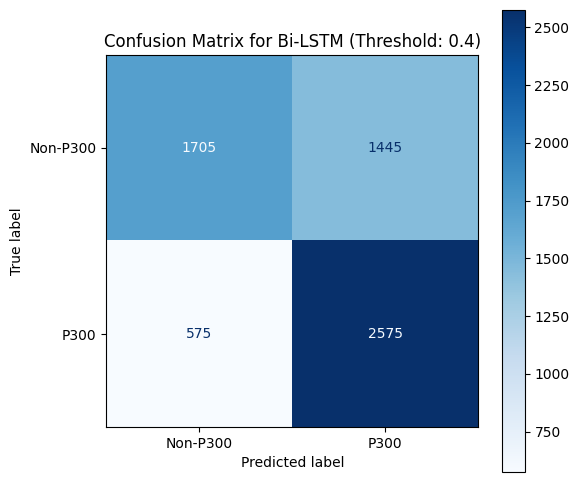

In [47]:
from sklearn.metrics import classification_report

# Apply learned threshold on TEST set
y_test_pred = (probs_test >= 0.4).astype(int)

print("\n--- FINAL TEST SET PERFORMANCE ---")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    y_test_true,
    y_test_pred,
    "Bi-LSTM",
    title_suffix=f" (Threshold: {0.4})"
)

Available metrics in history: ['auc', 'loss', 'precision_nonp300', 'precision_p300', 'recall_nonp300', 'recall_p300', 'val_auc', 'val_loss', 'val_precision_nonp300', 'val_precision_p300', 'val_recall_nonp300', 'val_recall_p300']


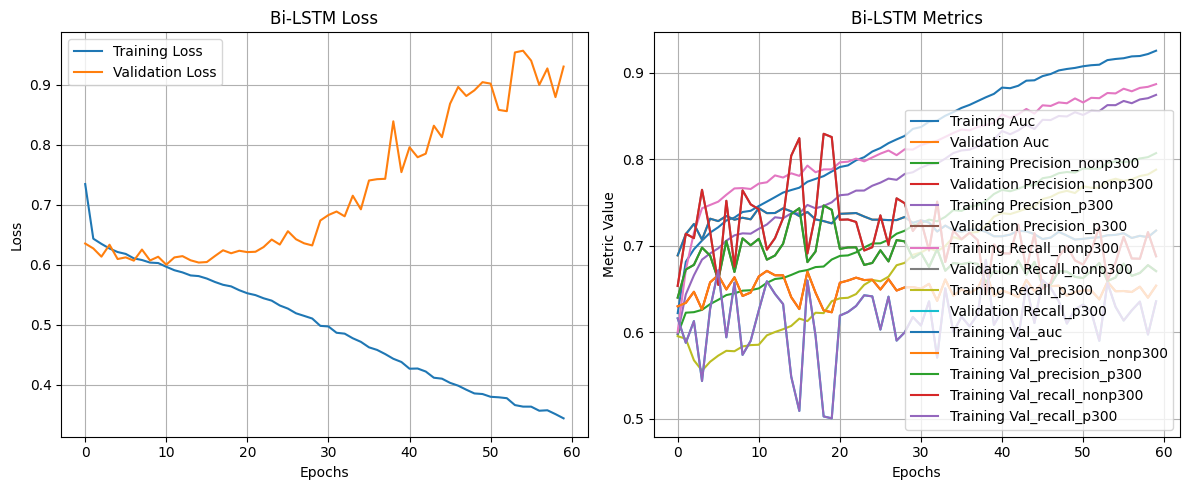

In [48]:
plot_training_history(history, "Bi-LSTM")

In [49]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

print("\n--- Training TGT-MHAG Model ---")

inp = Input(shape=input_shape)

x = Conv1D(32, 5, padding='same', activation='relu')(inp)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)

# Temporal Gated Attention
attn = Dense(32, activation='sigmoid')(x)
x = Multiply()([x, attn])

x = Conv1D(64, 3, padding='same', activation='relu')(x)
x = GlobalAveragePooling1D()(x)

x = Dense(64, activation='relu')(x)
out = Dense(num_classes, activation='softmax')(x)

model = Model(inp, out)

model.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=[tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300')
            ]
)

p300_ckpt = P300MacroF1Checkpoint(
    X_val_final,
    y_val_cat,
    filepath="TGT_MHAG_model_p300.h5"
)

history = model.fit(
    X_train_final, y_train_cat,
    validation_data=(X_val_final, y_val_cat),
    epochs=60,
    batch_size=16,
    callbacks=[p300_ckpt],
    verbose=1
)


--- Training TGT-MHAG Model ---
Epoch 1/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.5478 - loss: 0.6898 - precision_nonp300: 0.5336 - precision_p300: 0.5385 - recall_nonp300: 0.5233 - recall_p300: 0.5489  Saved best model — F1_macro: 0.3333 | F1_P300: 0.6667 | F1_NonP300: 0.0000
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - auc: 0.5478 - loss: 0.6898 - precision_nonp300: 0.5336 - precision_p300: 0.5385 - recall_nonp300: 0.5233 - recall_p300: 0.5489 - val_auc: 0.5153 - val_loss: 0.6928 - val_precision_nonp300: 0.5090 - val_precision_p300: 0.5742 - val_recall_nonp300: 0.9079 - val_recall_p300: 0.1241
Epoch 2/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - auc: 0.5688 - loss: 0.6867 - precision_nonp300: 0.5395 - precision_p300: 0.5564 - recall_nonp300: 0.5436 - recall_p300: 0.5521 - val_auc: 0.5253 - val_loss: 0.6923 - val_precision_nonp300: 0.5113 - val_precision_p300: 0.5435 - val_recall_nonp300: 0.8117 - val_recall_p300: 0.2241
Epoch 3/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 8s 4

In [50]:
from tensorflow.keras.models import load_model
model = load_model("TGT_MHAG_model_p300.h5")

In [51]:
# =========================
# Predict probabilities
# =========================

# Validation set (for threshold tuning)
probs_val = model.predict(X_val_final, verbose=0)[:, 1]
y_val_true = np.argmax(y_val_cat, axis=1)

# Test set (for final evaluation ONLY)
probs_test = model.predict(X_test_final, verbose=0)[:, 1]
y_test_true = y_test.astype(int)

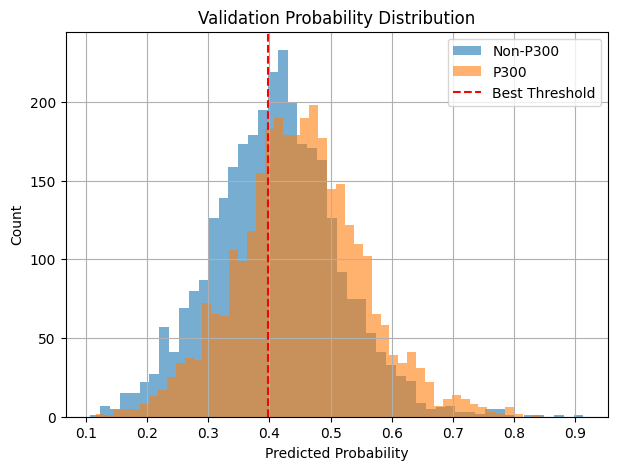

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(probs_val[y_val_true == 0], bins=50, alpha=0.6, label="Non-P300")
plt.hist(probs_val[y_val_true == 1], bins=50, alpha=0.6, label="P300")
plt.axvline(best_threshold, color='red', linestyle='--', label='Best Threshold')
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Validation Probability Distribution")
plt.legend()
plt.grid(True)
plt.show()

In [53]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_val_true,
    probs_val
)

# thresholds has length = len(precision) - 1
precision = precision[:-1]
recall = recall[:-1]

f1 = 2 * precision * recall / (precision + recall + 1e-8)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (VAL): {best_threshold:.4f}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall:    {recall[best_idx]:.4f}")
print(f"F1-score:  {f1[best_idx]:.4f}")

Best Threshold (VAL): 0.2273
Precision: 0.5060
Recall:    0.9860
F1-score:  0.6688



--- FINAL TEST SET PERFORMANCE ---
              precision    recall  f1-score   support

    Non-P300       0.58      0.44      0.50      3150
        P300       0.55      0.68      0.61      3150

    accuracy                           0.56      6300
   macro avg       0.56      0.56      0.55      6300
weighted avg       0.56      0.56      0.55      6300



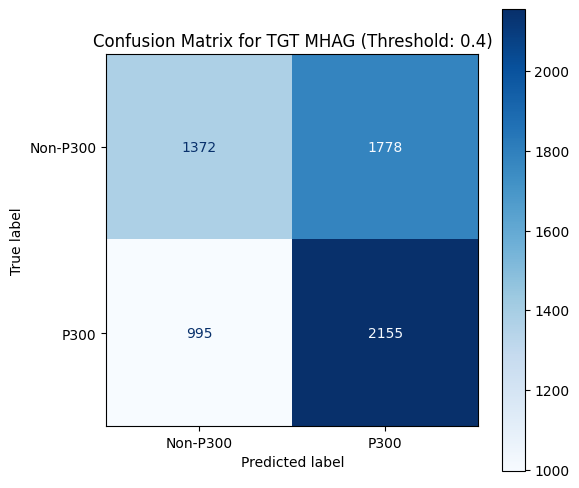

In [54]:
from sklearn.metrics import classification_report

# Apply learned threshold on TEST set
y_test_pred = (probs_test >= 0.4).astype(int)

print("\n--- FINAL TEST SET PERFORMANCE ---")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    y_test_true,
    y_test_pred,
    "TGT MHAG",
    title_suffix=f" (Threshold: {0.4})"
)

Available metrics in history: ['auc', 'loss', 'precision_nonp300', 'precision_p300', 'recall_nonp300', 'recall_p300', 'val_auc', 'val_loss', 'val_precision_nonp300', 'val_precision_p300', 'val_recall_nonp300', 'val_recall_p300']


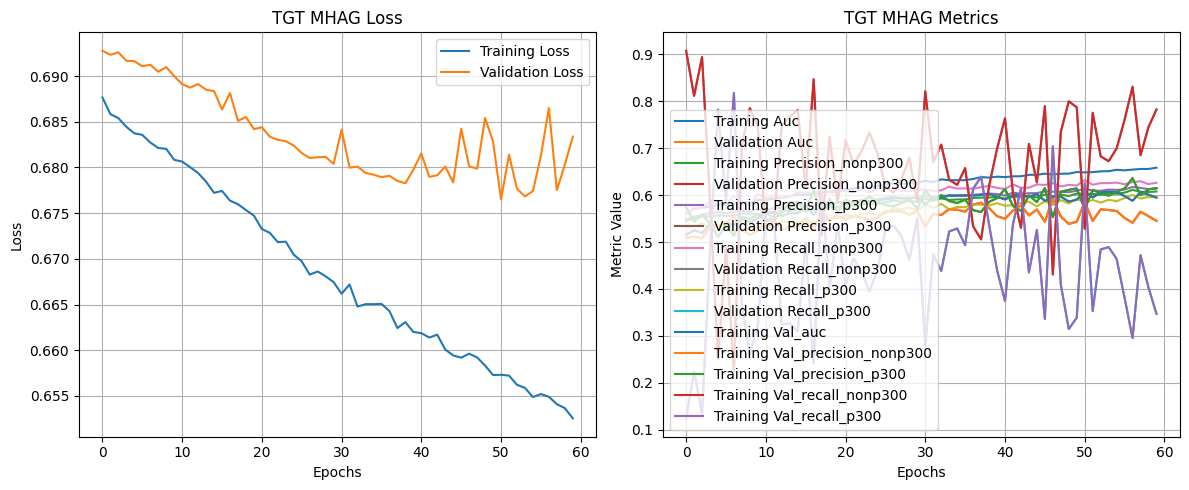

In [55]:
plot_training_history(history, "TGT MHAG")

In [56]:
from tensorflow.keras import backend as K

def channel_attention(x, ratio=8):
    ch = x.shape[-1]
    avg = GlobalAveragePooling1D()(x)
    maxp = GlobalMaxPooling1D()(x)
    shared = Dense(ch // ratio, activation='relu')
    avg = Dense(ch)(shared(avg))
    maxp = Dense(ch)(shared(maxp))
    attn = Activation('sigmoid')(avg + maxp)
    return Multiply()([x, attn])

def spatial_attention(x):
    avg = Lambda(lambda z: K.mean(z, axis=-1, keepdims=True))(x)
    maxp = Lambda(lambda z: K.max(z, axis=-1, keepdims=True))(x)
    concat = Concatenate()([avg, maxp])
    attn = Conv1D(1, 7, padding='same', activation='sigmoid')(concat)
    return Multiply()([x, attn])

def cbam_block(x):
    x = channel_attention(x)
    x = spatial_attention(x)
    return x

In [57]:
print("\n--- Training CBAM-BiLSTM Model ---")

inp = Input(shape=input_shape)

x = Conv1D(32, 5, padding='same', activation='relu')(inp)
x = cbam_block(x)
x = MaxPooling1D(2)(x)
x = Dropout(0.4)(x)

x = Bidirectional(LSTM(32, return_sequences=True))(x)
x = Dropout(0.4)(x)
x = Bidirectional(LSTM(16))(x)

x = Dense(64, activation='relu')(x)
out = Dense(num_classes, activation='softmax')(x)

model = Model(inp, out)

model.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=[tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
        tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
        tf.keras.metrics.Recall(class_id=0, name='recall_nonp300'),
        tf.keras.metrics.Precision(class_id=0, name='precision_nonp300')
    ]
)

p300_ckpt = P300MacroF1Checkpoint(
    X_val_final,
    y_val_cat,
    filepath="CBAM_BiLSTM_model_p300.h5"
)

history = model.fit(
    X_train_final, y_train_cat,
    validation_data=(X_val_final, y_val_cat),
    epochs=60,
    batch_size=16,
    callbacks=[p300_ckpt],
    verbose=1
)


--- Training CBAM-BiLSTM Model ---
Epoch 1/60
1837/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - auc: 0.5629 - loss: 0.6870 - precision_nonp300: 0.5396 - precision_p300: 0.5465 - recall_nonp300: 0.5857 - recall_p300: 0.4994  Saved best model — F1_macro: 0.3333 | F1_P300: 0.6667 | F1_NonP300: 0.0000
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 46s 20ms/step - auc: 0.5630 - loss: 0.6870 - precision_nonp300: 0.5396 - precision_p300: 0.5465 - recall_nonp300: 0.5857 - recall_p300: 0.4994 - val_auc: 0.5920 - val_loss: 0.6853 - val_precision_nonp300: 0.5733 - val_precision_p300: 0.5718 - val_recall_nonp300: 0.5676 - val_recall_p300: 0.5775
Epoch 2/60
1836/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - auc: 0.5920 - loss: 0.6800 - precision_nonp300: 0.5654 - precision_p300: 0.5693 - recall_nonp300: 0.5631 - recall_p300: 0.5714  Saved best model — F1_macro: 0.3343 | F1_P300: 0.6667 | F1_NonP300: 0.0019
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - auc: 0.5920 - loss: 0.6800 - precision_nonp300: 0.5654 - precision_p30

In [58]:
# =========================
# Predict probabilities
# =========================

# Validation set (for threshold tuning)
probs_val = model.predict(X_val_final, verbose=0)[:, 1]
y_val_true = np.argmax(y_val_cat, axis=1)

# Test set (for final evaluation ONLY)
probs_test = model.predict(X_test_final, verbose=0)[:, 1]
y_test_true = y_test.astype(int)

In [59]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_val_true,
    probs_val
)

# thresholds has length = len(precision) - 1
precision = precision[:-1]
recall = recall[:-1]

f1 = 2 * precision * recall / (precision + recall + 1e-8)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (VAL): {best_threshold:.4f}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall:    {recall[best_idx]:.4f}")
print(f"F1-score:  {f1[best_idx]:.4f}")

Best Threshold (VAL): 0.3180
Precision: 0.6136
Recall:    0.8635
F1-score:  0.7174


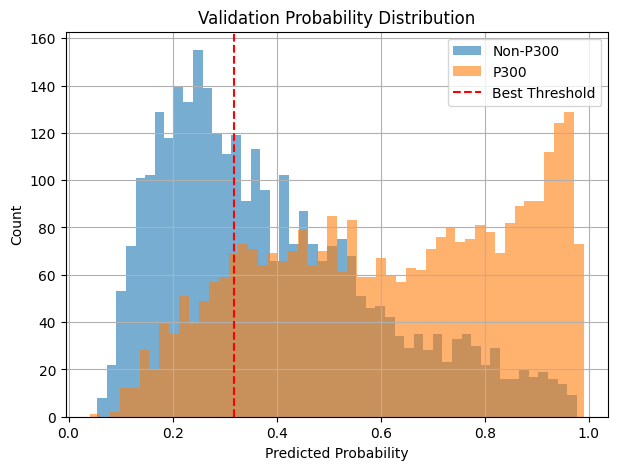

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(probs_val[y_val_true == 0], bins=50, alpha=0.6, label="Non-P300")
plt.hist(probs_val[y_val_true == 1], bins=50, alpha=0.6, label="P300")
plt.axvline(best_threshold, color='red', linestyle='--', label='Best Threshold')
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Validation Probability Distribution")
plt.legend()
plt.grid(True)
plt.show()


--- FINAL TEST SET PERFORMANCE ---
              precision    recall  f1-score   support

    Non-P300       0.73      0.61      0.66      3150
        P300       0.67      0.77      0.71      3150

    accuracy                           0.69      6300
   macro avg       0.70      0.69      0.69      6300
weighted avg       0.70      0.69      0.69      6300



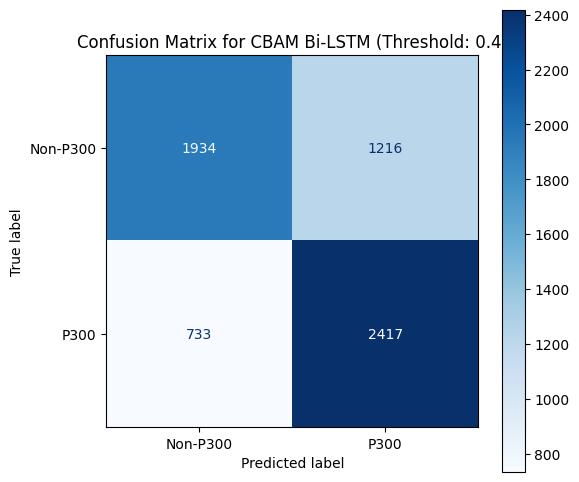

In [61]:
from sklearn.metrics import classification_report

# Apply learned threshold on TEST set
y_test_pred = (probs_test >= 0.4).astype(int)

print("\n--- FINAL TEST SET PERFORMANCE ---")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    y_test_true,
    y_test_pred,
    "CBAM Bi-LSTM",
    title_suffix=f" (Threshold: {0.4})"
)

In [62]:
p300_ckpt = P300MacroF1Checkpoint(
    X_val_final,
    y_val_cat,
    filepath="TGT_MHAG_CBAM_Bilstm_model_p300.h5"
)

In [63]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, DepthwiseConv1D, BatchNormalization,
    Activation, Dropout, GlobalAveragePooling1D,
    Dense, Multiply, Add, AveragePooling1D,
    Bidirectional, LSTM
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling1D, Dense, Activation, Multiply, Lambda

def CBAM_Channel_Attention(x, ratio=8):
    channel = x.shape[-1]

    # Global Average Pooling
    avg_out = GlobalAveragePooling1D()(x)
    
    # MLP
    avg_out = Dense(channel // ratio, activation='relu')(avg_out)
    avg_out = Dense(channel)(avg_out)
    
    # Sigmoid + expand dims
    scale = Activation('sigmoid')(avg_out)
    scale = Lambda(lambda s: tf.expand_dims(s, axis=1))(scale)  

    # Scale
    return Multiply()([x, scale])
def MultiScale_Temporal_Block(x, filters):
    conv3 = Conv1D(filters, 3, padding='same', activation='elu')(x)
    conv5 = Conv1D(filters, 5, padding='same', activation='elu')(x)
    conv7 = Conv1D(filters, 7, padding='same', activation='elu')(x)

    x = Add()([conv3, conv5, conv7])
    x = BatchNormalization()(x)
    return x


In [64]:
def build_TGTMHAG_CBAM_BiLSTM(input_shape=(100, 8), num_classes=2):
    inputs = Input(shape=input_shape)

    # ──────────────────────────────
    # Temporal Feature Extraction
    # ──────────────────────────────
    x = Conv1D(32, kernel_size=15, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = Dropout(0.3)(x)

    # ──────────────────────────────
    # Multi-Scale Temporal Learning
    # ──────────────────────────────
    x = MultiScale_Temporal_Block(x, filters=32)

    # ──────────────────────────────
    # Channel Attention (CBAM)
    # ──────────────────────────────
    x = CBAM_Channel_Attention(x, ratio=8)

    # ──────────────────────────────
    # Depthwise Channel Mixing
    # ──────────────────────────────
    x = DepthwiseConv1D(kernel_size=1, depth_multiplier=2)(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)

    # ──────────────────────────────
    # Temporal Downsampling
    # ──────────────────────────────
    x = AveragePooling1D(pool_size=4)(x)
    x = Dropout(0.3)(x)

    # ──────────────────────────────
    # BiLSTM (Latency Handling)
    # ──────────────────────────────
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    x = Bidirectional(LSTM(32))(x)
    x = Dropout(0.3)(x)

    # ──────────────────────────────
    # Classifier
    # ──────────────────────────────
    x = Dense(64, activation='elu')(x)
    x = Dropout(0.4)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=[
            tf.metrics.AUC(name='auc'),
        tf.metrics.Recall(class_id=1, name='recall_p300'),
        tf.metrics.Precision(class_id=1, name='precision_p300'),
        tf.metrics.Recall(class_id=0, name='recall_nonp300'),
        tf.metrics.Precision(class_id=0, name='precision_nonp300')
        ]
    )

    return model


In [65]:
model = build_TGTMHAG_CBAM_BiLSTM(
    input_shape,
    num_classes
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 100, 8)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 100, 32)   │      3,872 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 32)   │        128 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 100, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 100, 32)   │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 100, 32)   │      3,104 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 100, 32)   │      5,152 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 100, 32)   │      7,200 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 100, 32)   │          0 │ conv1d_8[0][0],   │
│                     │                   │            │ conv1d_9[0][0],   │
│                     │                   │            │ conv1d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 32)   │        128 │ add_1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 4)         │        132 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 32)        │        160 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32)        │          0 │ dense_13[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 1, 32)     │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 100, 32)   │          0 │ batch_normalizat… │
│ (Multiply)          │                   │            │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv1d    │ (None, 100, 64)   │        128 │ multiply_3[0][0]  │
│ (DepthwiseConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 64)   │        256 │ depthwise_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 100, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                 

 Total params: 131,814 (514.90 KB)

 Trainable params: 131,558 (513.90 KB)

 Non-trainable params: 256 (1.00 KB)

In [66]:
history = model.fit(
    X_train_final, y_train_cat,
    validation_data=(X_val_final, y_val_cat),
    epochs=60,
    batch_size=16,
    callbacks=[p300_ckpt],
    verbose=1
)

Epoch 1/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - auc: 0.5524 - loss: 0.6964 - precision_nonp300: 0.5341 - precision_p300: 0.5328 - recall_nonp300: 0.5249 - recall_p300: 0.5419  Saved best model — F1_macro: 0.3506 | F1_P300: 0.6677 | F1_NonP300: 0.0335
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 53s 22ms/step - auc: 0.5524 - loss: 0.6964 - precision_nonp300: 0.5341 - precision_p300: 0.5328 - recall_nonp300: 0.5249 - recall_p300: 0.5419 - val_auc: 0.6369 - val_loss: 0.6668 - val_precision_nonp300: 0.5912 - val_precision_p300: 0.6025 - val_recall_nonp300: 0.6257 - val_recall_p300: 0.5673
Epoch 2/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - auc: 0.6182 - loss: 0.6719 - precision_nonp300: 0.5855 - precision_p300: 0.5838 - recall_nonp300: 0.5909 - recall_p300: 0.5784  Saved best model — F1_macro: 0.4090 | F1_P300: 0.6732 | F1_NonP300: 0.1447
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - auc: 0.6182 - loss: 0.6719 - precision_nonp300: 0.5855 - precision_p300: 0.5838 - recall_nonp300: 0.5909 -

In [68]:
# =========================
# Predict probabilities
# =========================

# Validation set (for threshold tuning)
probs_val = model.predict(X_val_final, verbose=0)[:, 1]
y_val_true = np.argmax(y_val_cat, axis=1)

# Test set (for final evaluation ONLY)
probs_test = model.predict(X_test_final, verbose=0)[:, 1]
y_test_true = y_test.astype(int)


In [69]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_val_true,
    probs_val
)

# thresholds has length = len(precision) - 1
precision = precision[:-1]
recall = recall[:-1]

f1 = 2 * precision * recall / (precision + recall + 1e-8)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (VAL): {best_threshold:.4f}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall:    {recall[best_idx]:.4f}")
print(f"F1-score:  {f1[best_idx]:.4f}")

Best Threshold (VAL): 0.3663
Precision: 0.6442
Recall:    0.8117
F1-score:  0.7184


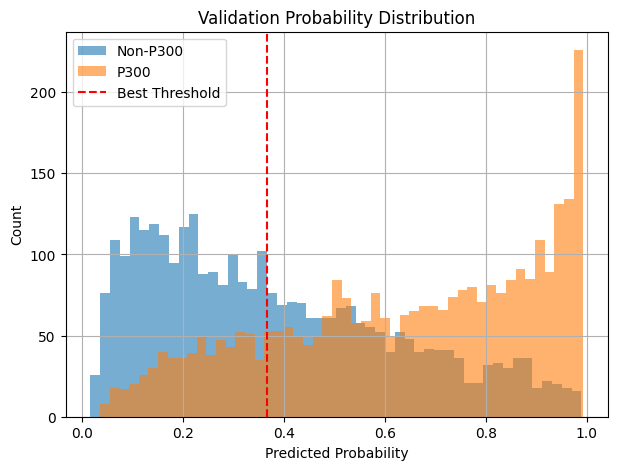

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(probs_val[y_val_true == 0], bins=50, alpha=0.6, label="Non-P300")
plt.hist(probs_val[y_val_true == 1], bins=50, alpha=0.6, label="P300")
plt.axvline(best_threshold, color='red', linestyle='--', label='Best Threshold')
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Validation Probability Distribution")
plt.legend()
plt.grid(True)
plt.show()


--- FINAL TEST SET PERFORMANCE ---
              precision    recall  f1-score   support

    Non-P300       0.74      0.62      0.67      3150
        P300       0.67      0.78      0.72      3150

    accuracy                           0.70      6300
   macro avg       0.70      0.70      0.70      6300
weighted avg       0.70      0.70      0.70      6300



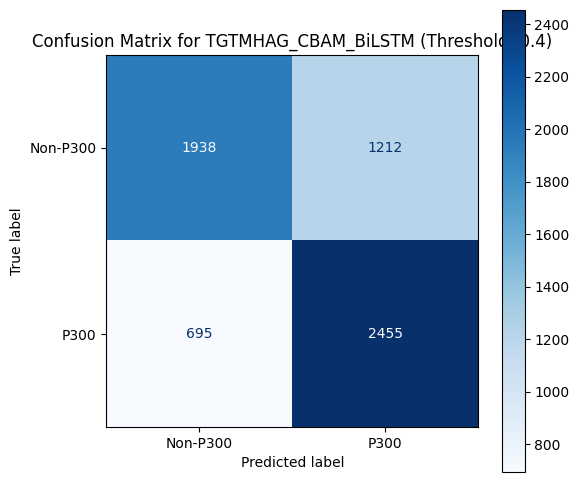

In [71]:
from sklearn.metrics import classification_report

# Apply learned threshold on TEST set
y_test_pred = (probs_test >= 0.4).astype(int)

print("\n--- FINAL TEST SET PERFORMANCE ---")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    y_test_true,
    y_test_pred,
    "TGTMHAG_CBAM_BiLSTM",
    title_suffix=f" (Threshold: {0.4})"
)


In [72]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, AveragePooling2D, Dropout,
    Flatten, Dense
)
from tensorflow.keras.models import Model


def build_p3cnet(input_shape, num_classes=2):
    inp = Input(shape=input_shape)

    # ------------------
    # Temporal filtering
    # ------------------
    k_t1 = max(3, int(input_shape[0] * 0.2))
    x = Conv2D(
        16, (k_t1, 1),
        padding="same",
        activation="relu"
    )(inp)
    x = BatchNormalization()(x)

    # ------------------
    # Spatial filtering
    # ------------------
    x = DepthwiseConv2D(
        (1, input_shape[1]),
        padding="valid",
        activation="relu"
    )(x)
    x = BatchNormalization()(x)

    # ------------------
    # Temporal pooling
    # ------------------
    pool_t1 = max(2, input_shape[0] // 30)
    x = AveragePooling2D((pool_t1, 1))(x)
    x = Dropout(0.3)(x)

    # ------------------
    # Higher-level temporal conv
    # ------------------
    k_t2 = max(3, input_shape[0] // 25)
    x = SeparableConv2D(
        32, (k_t2, 1),
        padding="same",
        activation="relu"
    )(x)
    x = BatchNormalization()(x)

    pool_t2 = max(2, input_shape[0] // 40)
    x = AveragePooling2D((pool_t2, 1))(x)
    x = Dropout(0.3)(x)

    # ------------------
    # Classification
    # ------------------
    x = Flatten()(x)
    out = Dense(num_classes, activation="softmax")(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="categorical_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(class_id=1, name="precision_p300"),
            tf.keras.metrics.Recall(class_id=1, name="recall_p300"),
            tf.keras.metrics.Precision(class_id=0, name="precision_nonp300"),
            tf.keras.metrics.Recall(class_id=0, name="recall_nonp300"),
          
        ]
    )

    return model


In [73]:
input_shape = X_train_final.shape[1:]
model = build_p3cnet(input_shape, num_classes)
model.summary()

p300_checkpoint = P300MacroF1Checkpoint(
    X_val_final,
    y_val_cat,
    "p3cnet_model_p300.h5"
)

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 100, 8, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 8, 16)     │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 100, 8, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 100, 1, 16)     │           144 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 100, 1, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 33, 1, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 33, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 33, 1, 32)      │           608 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 33, 1, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 16, 1, 32)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,370 (9.26 KB)

 Trainable params: 2,242 (8.76 KB)

 Non-trainable params: 128 (512.00 B)

In [74]:
history = model.fit(
    X_train_final, y_train_cat,
    validation_data=(X_val_final, y_val_cat),
    epochs=60,
    batch_size=16,
    callbacks=[p300_checkpoint],
    verbose=1,
    shuffle=True
)

Epoch 1/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc: 0.5584 - loss: 0.7880 - precision_nonp300: 0.5441 - precision_p300: 0.5429 - recall_nonp300: 0.5274 - recall_p300: 0.5595  Saved best model — F1_macro: 0.3453 | F1_P300: 0.6668 | F1_NonP300: 0.0237
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - auc: 0.5584 - loss: 0.7880 - precision_nonp300: 0.5441 - precision_p300: 0.5429 - recall_nonp300: 0.5274 - recall_p300: 0.5595 - val_auc: 0.6286 - val_loss: 0.6668 - val_precision_nonp300: 0.5910 - val_precision_p300: 0.5787 - val_recall_nonp300: 0.5483 - val_recall_p300: 0.6206
Epoch 2/60
1835/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.6428 - loss: 0.6662 - precision_nonp300: 0.6027 - precision_p300: 0.6062 - recall_nonp300: 0.5954 - recall_p300: 0.6133  Saved best model — F1_macro: 0.4504 | F1_P300: 0.6752 | F1_NonP300: 0.2256
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - auc: 0.6428 - loss: 0.6661 - precision_nonp300: 0.6027 - precision_p300: 0.6062 - recall_nonp300: 0.5955 - reca

In [75]:
# =========================
# Predict probabilities
# =========================

# Validation set (for threshold tuning)
probs_val = model.predict(X_val_final, verbose=0)[:, 1]
y_val_true = np.argmax(y_val_cat, axis=1)

# Test set (for final evaluation ONLY)
probs_test = model.predict(X_test_final, verbose=0)[:, 1]
y_test_true = y_test.astype(int)


In [76]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_val_true,
    probs_val
)

# thresholds has length = len(precision) - 1
precision = precision[:-1]
recall = recall[:-1]

f1 = 2 * precision * recall / (precision + recall + 1e-8)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (VAL): {best_threshold:.4f}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall:    {recall[best_idx]:.4f}")
print(f"F1-score:  {f1[best_idx]:.4f}")

Best Threshold (VAL): 0.3566
Precision: 0.6252
Recall:    0.8235
F1-score:  0.7108


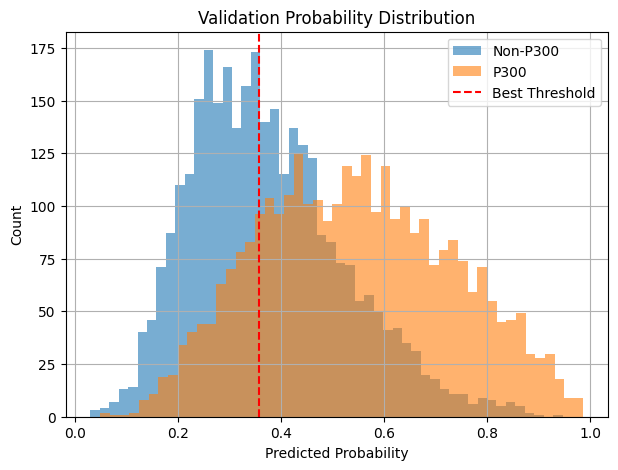

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(probs_val[y_val_true == 0], bins=50, alpha=0.6, label="Non-P300")
plt.hist(probs_val[y_val_true == 1], bins=50, alpha=0.6, label="P300")
plt.axvline(best_threshold, color='red', linestyle='--', label='Best Threshold')
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Validation Probability Distribution")
plt.legend()
plt.grid(True)
plt.show()


--- FINAL TEST SET PERFORMANCE ---
              precision    recall  f1-score   support

    Non-P300       0.72      0.64      0.67      3150
        P300       0.67      0.75      0.71      3150

    accuracy                           0.69      6300
   macro avg       0.69      0.69      0.69      6300
weighted avg       0.69      0.69      0.69      6300



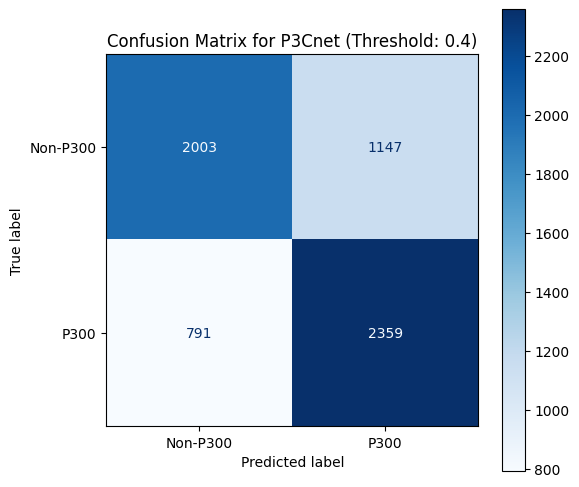

In [78]:
from sklearn.metrics import classification_report

# Apply learned threshold on TEST set
y_test_pred = (probs_test >= 0.4).astype(int)

print("\n--- FINAL TEST SET PERFORMANCE ---")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    y_test_true,
    y_test_pred,
    "P3Cnet",
    title_suffix=f" (Threshold: {0.4})"
)


Available metrics in history: ['auc', 'loss', 'precision_nonp300', 'precision_p300', 'recall_nonp300', 'recall_p300', 'val_auc', 'val_loss', 'val_precision_nonp300', 'val_precision_p300', 'val_recall_nonp300', 'val_recall_p300']


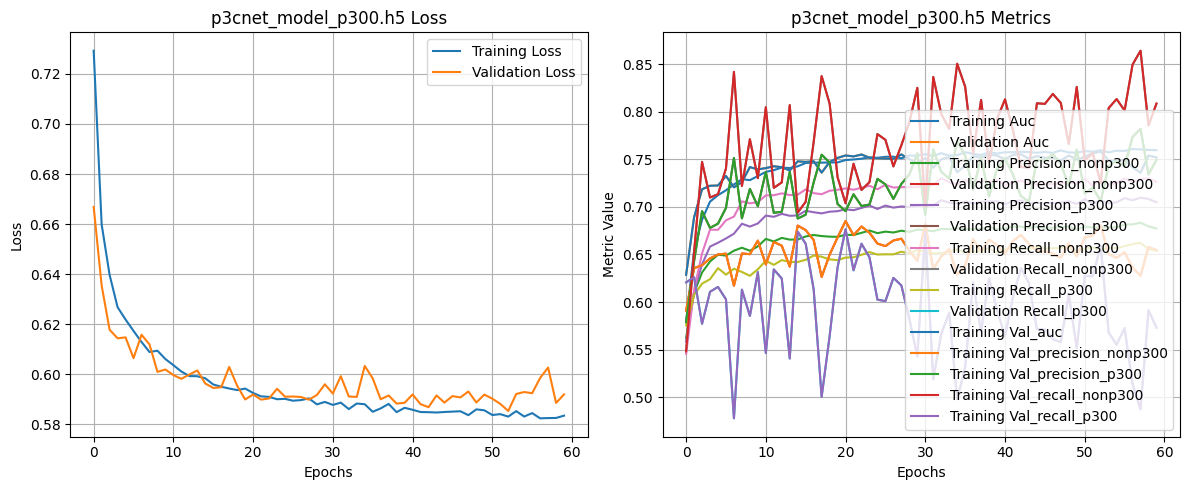

In [80]:
plot_training_history(history, "p3cnet_model_p300.h5")

In [81]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, Activation, AveragePooling2D,
    Dropout, Flatten, Dense
)
from tensorflow.keras.models import Model
from tensorflow.keras.constraints import max_norm

In [82]:
def build_eegnet(
    input_shape,
    num_classes=2,
    F1=8,
    D=2,
    F2=16,
    dropout_rate=0.5
):
    """
    EEGNet for P300 classification
    Input shape: (T, C, 1)
    """

    inp = Input(shape=input_shape)

    # ---------------------------------
    # Block 1: Temporal Convolution
    # ---------------------------------
    x = Conv2D(
        F1,
        (64, 1),            # temporal kernel (~250 ms @ 256Hz)
        padding='same',
        use_bias=False
    )(inp)
    x = BatchNormalization()(x)

    # ---------------------------------
    # Block 2: Spatial Filtering
    # ---------------------------------
    x = DepthwiseConv2D(
        (1, input_shape[1]),
        use_bias=False,
        depth_multiplier=D,
        depthwise_constraint=max_norm(1.0)
    )(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)

    x = AveragePooling2D((4, 1))(x)
    x = Dropout(dropout_rate)(x)

    # ---------------------------------
    # Block 3: Separable Convolution
    # ---------------------------------
    x = SeparableConv2D(
        F2,
        (16, 1),
        padding='same',
        use_bias=False
    )(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)

    x = AveragePooling2D((8, 1))(x)
    x = Dropout(dropout_rate)(x)

    # ---------------------------------
    # Classification
    # ---------------------------------
    x = Flatten()(x)
    out = Dense(
        num_classes,
        activation='softmax',
        kernel_constraint=max_norm(0.25)
    )(x)

    model = Model(inp, out, name="EEGNet")

    return model

In [83]:
model = build_eegnet(
    input_shape=X_train_final.shape[1:],
    num_classes=2,
    dropout_rate=0.5
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
        tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
        tf.keras.metrics.Precision(class_id=0, name='precision_nonp300'),
        tf.keras.metrics.Recall(class_id=0, name='recall_nonp300'),
        
    ]
)

model.summary()

p300_chkpoint = P300MacroF1Checkpoint(
    X_val_final,
    y_val_cat,
    "EEGNet_model_p300.h5"
)

Model: "EEGNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 100, 8, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 8, 8)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 100, 8, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 100, 1, 16)     │           128 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 100, 1, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 100, 1, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 25, 1, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 25, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 25, 1, 16)      │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 25, 1, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 25, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 3, 1, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 3, 1, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 2)              │            98 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,410 (5.51 KB)

 Trainable params: 1,330 (5.20 KB)

 Non-trainable params: 80 (320.00 B)

In [84]:
history = model.fit(
    X_train_final, y_train_cat,
    validation_data=(X_val_final, y_val_cat),
    epochs=60,
    batch_size=16,
    callbacks=[p300_chkpoint],
    verbose=1,
    shuffle=True
)

Epoch 1/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc: 0.6168 - loss: 0.6709 - precision_nonp300: 0.5847 - precision_p300: 0.5833 - recall_nonp300: 0.5530 - recall_p300: 0.6149  Saved best model — F1_macro: 0.4112 | F1_P300: 0.6751 | F1_NonP300: 0.1473
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - auc: 0.6169 - loss: 0.6708 - precision_nonp300: 0.5847 - precision_p300: 0.5833 - recall_nonp300: 0.5531 - recall_p300: 0.6149 - val_auc: 0.6982 - val_loss: 0.6363 - val_precision_nonp300: 0.6321 - val_precision_p300: 0.6636 - val_recall_nonp300: 0.6994 - val_recall_p300: 0.5930
Epoch 2/60
1830/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.6871 - loss: 0.6387 - precision_nonp300: 0.6320 - precision_p300: 0.6427 - recall_nonp300: 0.6486 - recall_p300: 0.6258  Saved best model — F1_macro: 0.4802 | F1_P300: 0.6839 | F1_NonP300: 0.2766
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - auc: 0.6872 - loss: 0.6387 - precision_nonp300: 0.6320 - precision_p300: 0.6427 - recall_nonp300: 0.6487 - reca

In [85]:
model=load_model("EEGNet_model_p300.h5")

In [86]:
# =========================
# Predict probabilities
# =========================

# Validation set (for threshold tuning)
probs_val = model.predict(X_val_final, verbose=0)[:, 1]
y_val_true = np.argmax(y_val_cat, axis=1)

# Test set (for final evaluation ONLY)
probs_test = model.predict(X_test_final, verbose=0)[:, 1]
y_test_true = y_test.astype(int)


In [87]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, probs_val)

In [88]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_val_true,
    probs_val
)

# thresholds has length = len(precision) - 1
precision = precision[:-1]
recall = recall[:-1]

f1 = 2 * precision * recall / (precision + recall + 1e-8)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (VAL): {best_threshold:.4f}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall:    {recall[best_idx]:.4f}")
print(f"F1-score:  {f1[best_idx]:.4f}")

Best Threshold (VAL): 0.3546
Precision: 0.6225
Recall:    0.8419
F1-score:  0.7158


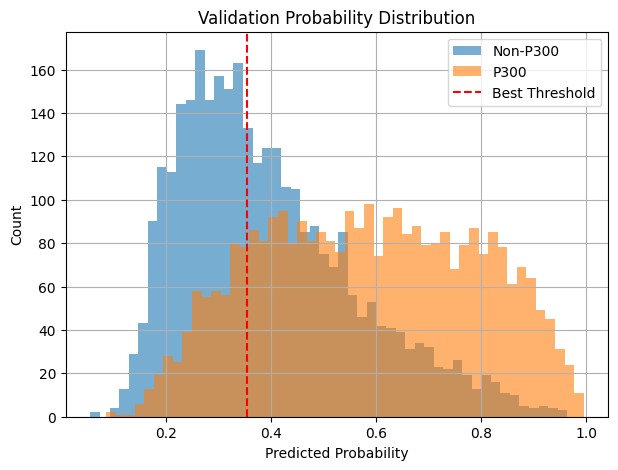

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(probs_val[y_val_true == 0], bins=50, alpha=0.6, label="Non-P300")
plt.hist(probs_val[y_val_true == 1], bins=50, alpha=0.6, label="P300")
plt.axvline(best_threshold, color='red', linestyle='--', label='Best Threshold')
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Validation Probability Distribution")
plt.legend()
plt.grid(True)
plt.show()


--- FINAL TEST SET PERFORMANCE ---
              precision    recall  f1-score   support

    Non-P300       0.73      0.60      0.66      3150
        P300       0.66      0.77      0.71      3150

    accuracy                           0.69      6300
   macro avg       0.69      0.69      0.69      6300
weighted avg       0.69      0.69      0.69      6300



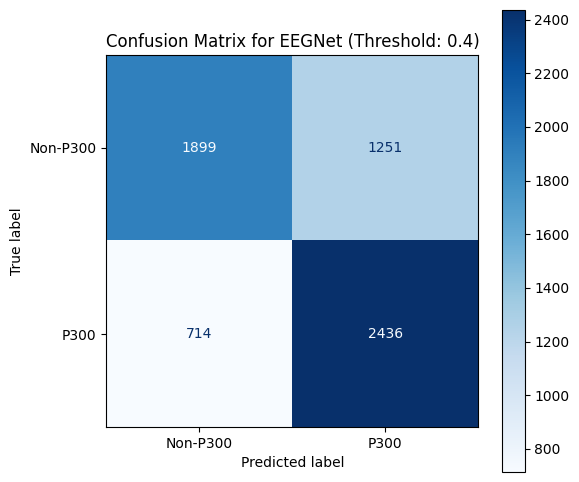

In [91]:
from sklearn.metrics import classification_report

# Apply learned threshold on TEST set
y_test_pred = (probs_test >= 0.4).astype(int)

print("\n--- FINAL TEST SET PERFORMANCE ---")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    y_test_true,
    y_test_pred,
    "EEGNet",
    title_suffix=f" (Threshold: {0.4})"
)


Available metrics in history: ['auc', 'loss', 'precision_nonp300', 'precision_p300', 'recall_nonp300', 'recall_p300', 'val_auc', 'val_loss', 'val_precision_nonp300', 'val_precision_p300', 'val_recall_nonp300', 'val_recall_p300']


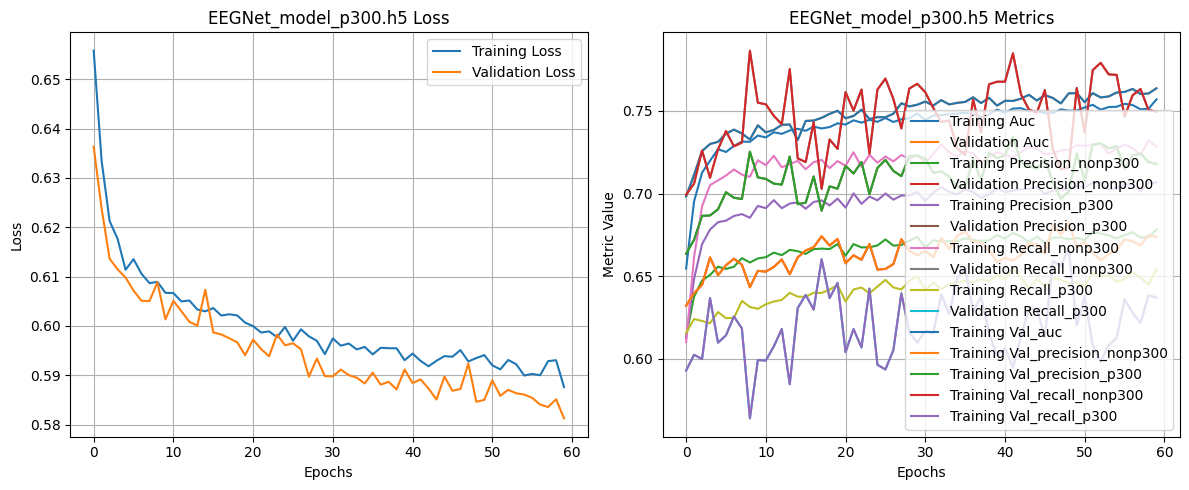

In [92]:
plot_training_history(history, "EEGNet_model_p300.h5")

In [93]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

In [103]:
from tensorflow.keras.layers import Lambda, Conv2D, Concatenate, Multiply

def spatial_attention(x):
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)

    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    out = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)

    return Multiply()([x, out])
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, GlobalMaxPooling2D, Reshape, Add

def channel_attention(x, ratio=8):
    channel = x.shape[-1]

    avg_pool = GlobalAveragePooling2D()(x)
    max_pool = GlobalMaxPooling2D()(x)

    shared_dense_1 = Dense(channel // ratio, activation='relu')
    shared_dense_2 = Dense(channel)

    avg_out = shared_dense_2(shared_dense_1(avg_pool))
    max_out = shared_dense_2(shared_dense_1(max_pool))

    out = Add()([avg_out, max_out])
    out = Activation('sigmoid')(out)

    out = Reshape((1, 1, channel))(out)
    return Multiply()([x, out])
def cbam_block(x):
    x = channel_attention(x)
    x = spatial_attention(x)
    return x

In [104]:
from tensorflow.keras.layers import Conv2D, BatchNormalization, Add, Activation

def residual_cbam_block(x, filters, stride=1):
    shortcut = x

    x = Conv2D(filters, 3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    x = cbam_block(x)

    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x

In [105]:
def build_cbam_resnet_eeg(input_shape, num_classes=2):
    inp = Input(shape=input_shape)

    x = Conv2D(32, (3,3), padding='same')(inp)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = residual_cbam_block(x, 32)
    x = residual_cbam_block(x, 32)

    x = residual_cbam_block(x, 64, stride=2)
    x = residual_cbam_block(x, 64)

    x = residual_cbam_block(x, 128, stride=2)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)

    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300'),
        ]
    )

    return model

In [106]:
model = build_cbam_resnet_eeg(
    input_shape=X_train_final.shape[1:],
    num_classes=2
)

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 100, 8, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 100, 8,    │        320 │ input_layer_9[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 8,    │        128 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 100, 8,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 100, 8,    │      9,248 │ activation_10[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 8,    │        128 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 100, 8,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 100, 8,    │      9,248 │ activation_11[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 8,    │        128 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 4)         │        132 │ global_average_p… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 32)        │        160 │ dense_22[0][0],   │
│                     │                   │            │ dense_22[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 32)        │          0 │ dense_23[0][0],   │
│                     │                   │            │ dense_23[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 32)        │          0 │ add_4[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 1, 32)  │          0 │ activation_12[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 100, 8,    │          0 │ batch_normalizat… │
│ (Multiply)          │ 32)               │            │ reshape_2[0][0] 

 Total params: 409,689 (1.56 MB)

 Trainable params: 407,961 (1.56 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [107]:
P300_chkpt = P300MacroF1Checkpoint(
    X_val_final,
    y_val_cat,
    "CBAM_RESNet_model_p300.h5"
    )

history = model.fit(
    X_train_final, y_train_cat,
    validation_data=(X_val_final, y_val_cat),
    epochs=60,
    batch_size=16,
    callbacks=[P300_chkpt],
    verbose=1,
    shuffle=True
)

Epoch 1/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - auc: 0.5260 - loss: 0.7303 - precision_nonp300: 0.5247 - precision_p300: 0.5167 - recall_nonp300: 0.5271 - recall_p300: 0.5144  Saved best model — F1_macro: 0.3333 | F1_P300: 0.6667 | F1_NonP300: 0.0000
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 72s 22ms/step - auc: 0.5260 - loss: 0.7303 - precision_nonp300: 0.5247 - precision_p300: 0.5167 - recall_nonp300: 0.5271 - recall_p300: 0.5144 - val_auc: 0.5126 - val_loss: 0.6931 - val_precision_nonp300: 0.5263 - val_precision_p300: 0.5003 - val_recall_nonp300: 0.0127 - val_recall_p300: 0.9886
Epoch 2/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - auc: 0.5631 - loss: 0.6882 - precision_nonp300: 0.5426 - precision_p300: 0.5430 - recall_nonp300: 0.5512 - recall_p300: 0.5343 - val_auc: 0.5188 - val_loss: 0.6934 - val_precision_nonp300: 0.5417 - val_precision_p300: 0.5002 - val_recall_nonp300: 0.0041 - val_recall_p300: 0.9965
Epoch 3/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - auc: 0.5667 - los

In [108]:
# =========================
# Predict probabilities
# =========================

# Validation set (for threshold tuning)
probs_val = model.predict(X_val_final, verbose=0)[:, 1]
y_val_true = np.argmax(y_val_cat, axis=1)

# Test set (for final evaluation ONLY)
probs_test = model.predict(X_test_final, verbose=0)[:, 1]
y_test_true = y_test.astype(int)

In [109]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, probs_val)

In [110]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_val_true,
    probs_val
)

# thresholds has length = len(precision) - 1
precision = precision[:-1]
recall = recall[:-1]

f1 = 2 * precision * recall / (precision + recall + 1e-8)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (VAL): {best_threshold:.4f}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall:    {recall[best_idx]:.4f}")
print(f"F1-score:  {f1[best_idx]:.4f}")

Best Threshold (VAL): 0.0538
Precision: 0.5536
Recall:    0.8711
F1-score:  0.6769



--- FINAL TEST SET PERFORMANCE ---
              precision    recall  f1-score   support

    Non-P300       0.64      0.66      0.65      3150
        P300       0.65      0.63      0.64      3150

    accuracy                           0.64      6300
   macro avg       0.64      0.64      0.64      6300
weighted avg       0.64      0.64      0.64      6300



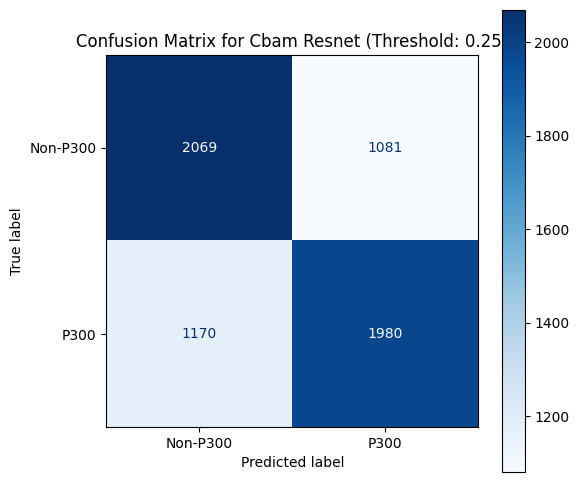

In [120]:
from sklearn.metrics import classification_report

# Apply learned threshold on TEST set
y_test_pred = (probs_test >= 0.25).astype(int)

print("\n--- FINAL TEST SET PERFORMANCE ---")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    y_test_true,
    y_test_pred,
    "Cbam Resnet",
    title_suffix=f" (Threshold: {0.25})"
)

Available metrics in history: ['auc', 'loss', 'precision_nonp300', 'precision_p300', 'recall_nonp300', 'recall_p300', 'val_auc', 'val_loss', 'val_precision_nonp300', 'val_precision_p300', 'val_recall_nonp300', 'val_recall_p300']


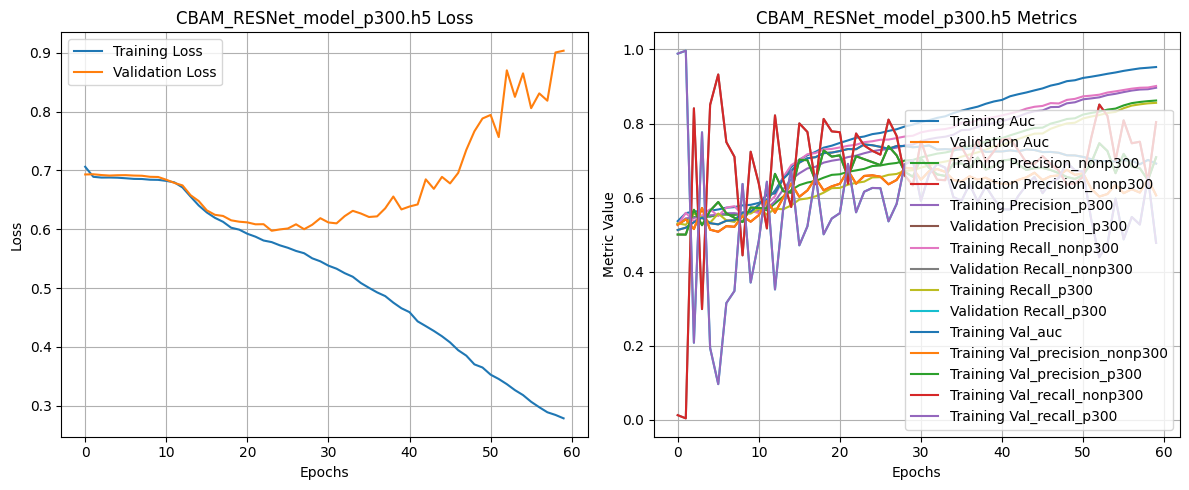

In [112]:
plot_training_history(history, "CBAM_RESNet_model_p300.h5")

In [121]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, GlobalMaxPooling2D,
    Dense, Reshape, Multiply, Add
)

def channel_attention(x, ratio=8):
    channel = x.shape[-1]

    avg_pool = GlobalAveragePooling2D()(x)
    max_pool = GlobalMaxPooling2D()(x)

    shared_dense_1 = Dense(channel // ratio, activation="relu", use_bias=False)
    shared_dense_2 = Dense(channel, use_bias=False)

    avg_out = shared_dense_2(shared_dense_1(avg_pool))
    max_out = shared_dense_2(shared_dense_1(max_pool))

    attn = Add()([avg_out, max_out])
    attn = tf.keras.activations.sigmoid(attn)
    attn = Reshape((1, 1, channel))(attn)

    return Multiply()([x, attn])
from tensorflow.keras.layers import Lambda, Concatenate, Conv2D

def spatial_attention(x):
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)

    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    attn = Conv2D(1, kernel_size=7, padding="same", activation="sigmoid")(concat)

    return Multiply()([x, attn])
def cbam_block(x):
    x = channel_attention(x)
    x = spatial_attention(x)
    return x

In [122]:
from tensorflow.keras.layers import Conv2D, Concatenate

def inception_block(x, filters):
    b1 = Conv2D(filters, (1,1), padding="same", activation="relu")(x)

    b2 = Conv2D(filters, (3,1), padding="same", activation="relu")(x)

    b3 = Conv2D(filters, (5,1), padding="same", activation="relu")(x)

    x = Concatenate(axis=-1)([b1, b2, b3])
    return x

In [126]:
def build_cbam_inception_eeg(input_shape, num_classes=2):
    inp = Input(shape=input_shape)

    x = Conv2D(32, (3,1), padding='same', activation='relu')(inp)
    x = BatchNormalization()(x)

    # Inception + CBAM stack
    x = inception_block(x, 16)
    x = cbam_block(x)
    x = Dropout(0.3)(x)

    x = inception_block(x, 32)
    x = cbam_block(x)
    x = Dropout(0.3)(x)

    x = inception_block(x, 64)
    x = cbam_block(x)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)

    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inp, out)
    
    model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(class_id=1, name="precision_p300"),
        tf.keras.metrics.Recall(class_id=1, name="recall_p300"),
        tf.keras.metrics.Precision(class_id=0, name="precision_nonp300"),
        tf.keras.metrics.Recall(class_id=0, name="recall_nonp300"),
    ]
)

    return model


In [129]:
model = build_cbam_inception_eeg(input_shape, num_classes)

In [131]:
P300_chkpnt = P300MacroF1Checkpoint(
    X_val_final,
    y_val_cat,
    "CBAM_InceptionNet_model_p300.h5"
    )
history = model.fit(
    X_train_final, y_train_cat,
    validation_data=(X_val_final, y_val_cat),
    epochs=60,
    batch_size=16,
    callbacks=[P300_chkpnt],
    verbose=1,
    shuffle=True
)

Epoch 1/60
1835/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.5985 - loss: 0.6780 - precision_nonp300: 0.5676 - precision_p300: 0.5729 - recall_nonp300: 0.5935 - recall_p300: 0.5464  Saved best model — F1_macro: 0.3796 | F1_P300: 0.6637 | F1_NonP300: 0.0955
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - auc: 0.5985 - loss: 0.6780 - precision_nonp300: 0.5676 - precision_p300: 0.5729 - recall_nonp300: 0.5936 - recall_p300: 0.5464 - val_auc: 0.5541 - val_loss: 0.6947 - val_precision_nonp300: 0.5260 - val_precision_p300: 0.5880 - val_recall_nonp300: 0.8121 - val_recall_p300: 0.2683
Epoch 2/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - auc: 0.5986 - loss: 0.6779 - precision_nonp300: 0.5672 - precision_p300: 0.5698 - recall_nonp300: 0.5947 - recall_p300: 0.5419 - val_auc: 0.5525 - val_loss: 0.6937 - val_precision_nonp300: 0.5236 - val_precision_p300: 0.5885 - val_recall_nonp300: 0.8267 - val_recall_p300: 0.2479
Epoch 3/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - auc: 0.6015 - loss: 0

In [132]:
# =========================
# Predict probabilities
# =========================

# Validation set (for threshold tuning)
probs_val = model.predict(X_val_final, verbose=0)[:, 1]
y_val_true = np.argmax(y_val_cat, axis=1)

# Test set (for final evaluation ONLY)
probs_test = model.predict(X_test_final, verbose=0)[:, 1]
y_test_true = y_test.astype(int)

In [133]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, probs_val)

In [134]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_val_true,
    probs_val
)

# thresholds has length = len(precision) - 1
precision = precision[:-1]
recall = recall[:-1]

f1 = 2 * precision * recall / (precision + recall + 1e-8)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (VAL): {best_threshold:.4f}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall:    {recall[best_idx]:.4f}")
print(f"F1-score:  {f1[best_idx]:.4f}")

Best Threshold (VAL): 0.1906
Precision: 0.5007
Recall:    0.9997
F1-score:  0.6672



--- FINAL TEST SET PERFORMANCE ---
              precision    recall  f1-score   support

    Non-P300       0.55      0.34      0.42      3150
        P300       0.52      0.73      0.61      3150

    accuracy                           0.53      6300
   macro avg       0.54      0.53      0.51      6300
weighted avg       0.54      0.53      0.51      6300



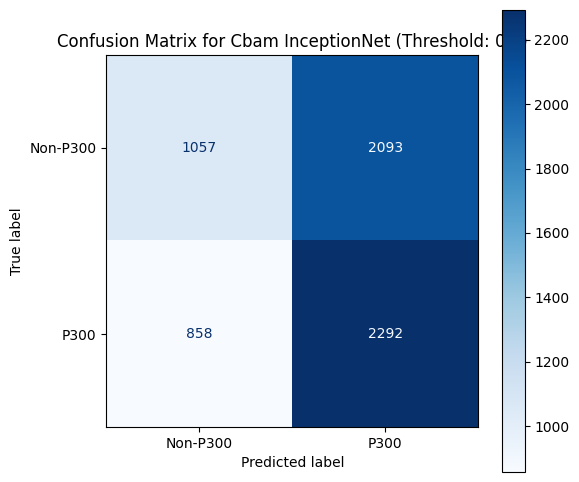

In [143]:
from sklearn.metrics import classification_report

# Apply learned threshold on TEST set
y_test_pred = (probs_test >= 0.4).astype(int)

print("\n--- FINAL TEST SET PERFORMANCE ---")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    y_test_true,
    y_test_pred,
    "Cbam InceptionNet",
    title_suffix=f" (Threshold: {0.4})"
)

Available metrics in history: ['auc', 'loss', 'precision_nonp300', 'precision_p300', 'recall_nonp300', 'recall_p300', 'val_auc', 'val_loss', 'val_precision_nonp300', 'val_precision_p300', 'val_recall_nonp300', 'val_recall_p300']


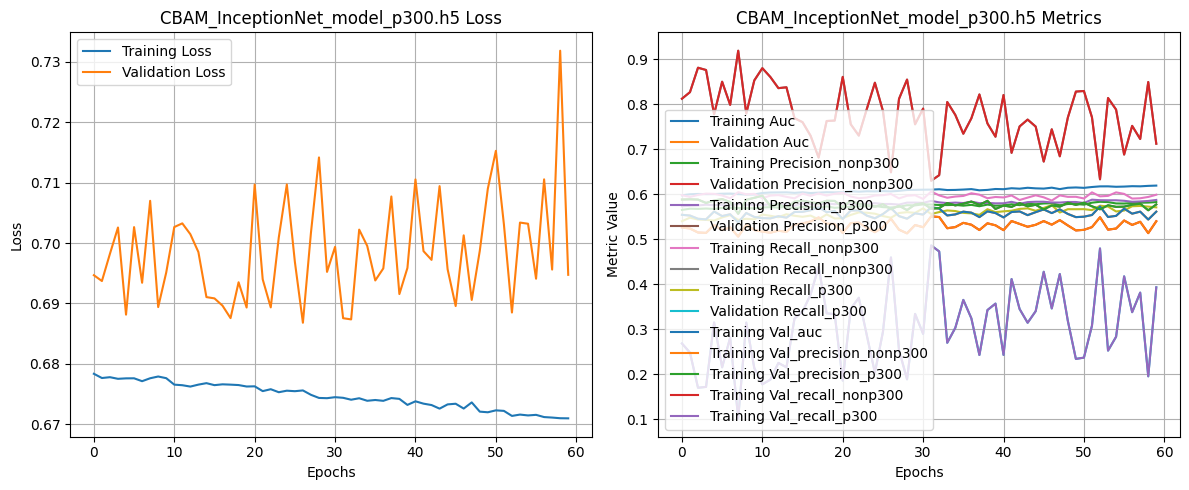

In [136]:
plot_training_history(history, "CBAM_InceptionNet_model_p300.h5")

In [144]:
def eeg_conv_block(x, filters):
    x = Conv2D(filters, (3,1), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(filters, (3,1), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = cbam_block(x)
    return x
def build_cbam_unet_eeg(input_shape, num_classes=2):
    inp = Input(shape=input_shape)

    # ---------- Encoder ----------
    c1 = eeg_conv_block(inp, 32)
    p1 = AveragePooling2D((2,1))(c1)

    c2 = eeg_conv_block(p1, 64)
    p2 = AveragePooling2D((2,1))(c2)

    c3 = eeg_conv_block(p2, 128)
    p3 = AveragePooling2D((2,1))(c3)

    # ---------- Bottleneck ----------
    bn = eeg_conv_block(p3, 256)

    # ---------- Decoder ----------
    u3 = UpSampling2D((2,1))(bn)
    u3 = Concatenate()([u3, c3])
    c4 = eeg_conv_block(u3, 128)

    u2 = UpSampling2D((2,1))(c4)
    u2 = Concatenate()([u2, c2])
    c5 = eeg_conv_block(u2, 64)

    u1 = UpSampling2D((2,1))(c5)
    u1 = Concatenate()([u1, c1])
    c6 = eeg_conv_block(u1, 32)

    # ---------- Classifier ----------
    x = GlobalAveragePooling2D()(c6)
    x = Dropout(0.4)(x)

    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300')
        ]
    )

    return model

In [145]:
P300_chckpnt = P300MacroF1Checkpoint(
    X_val_final,
    y_val_cat,
    "CBAM_UNet_model_p300.h5"
    )
history = model.fit(
    X_train_final, y_train_cat,
    validation_data=(X_val_final, y_val_cat),
    epochs=60,
    batch_size=16,
    callbacks=[P300_chckpnt],
    verbose=1,
    shuffle=True
)

Epoch 1/60
1833/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.6206 - loss: 0.6700 - precision_nonp300: 0.5841 - precision_p300: 0.5907 - recall_nonp300: 0.5728 - recall_p300: 0.6014  Saved best model — F1_macro: 0.4157 | F1_P300: 0.6586 | F1_NonP300: 0.1728
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - auc: 0.6206 - loss: 0.6700 - precision_nonp300: 0.5841 - precision_p300: 0.5907 - recall_nonp300: 0.5728 - recall_p300: 0.6013 - val_auc: 0.5453 - val_loss: 0.7023 - val_precision_nonp300: 0.5189 - val_precision_p300: 0.5669 - val_recall_nonp300: 0.8089 - val_recall_p300: 0.2502
Epoch 2/60
1836/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.6140 - loss: 0.6730 - precision_nonp300: 0.5795 - precision_p300: 0.5865 - recall_nonp300: 0.6000 - recall_p300: 0.5658  Saved best model — F1_macro: 0.4415 | F1_P300: 0.6507 | F1_NonP300: 0.2324
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - auc: 0.6140 - loss: 0.6730 - precision_nonp300: 0.5795 - precision_p300: 0.5865 - recall_nonp300: 0.6000 - r

In [146]:
# =========================
# Predict probabilities
# =========================

# Validation set (for threshold tuning)
probs_val = model.predict(X_val_final, verbose=0)[:, 1]
y_val_true = np.argmax(y_val_cat, axis=1)

# Test set (for final evaluation ONLY)
probs_test = model.predict(X_test_final, verbose=0)[:, 1]
y_test_true = y_test.astype(int)

In [147]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, probs_val)

In [148]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_val_true,
    probs_val
)

# thresholds has length = len(precision) - 1
precision = precision[:-1]
recall = recall[:-1]

f1 = 2 * precision * recall / (precision + recall + 1e-8)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (VAL): {best_threshold:.4f}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall:    {recall[best_idx]:.4f}")
print(f"F1-score:  {f1[best_idx]:.4f}")

Best Threshold (VAL): 0.0513
Precision: 0.5000
Recall:    1.0000
F1-score:  0.6667



--- FINAL TEST SET PERFORMANCE ---
              precision    recall  f1-score   support

    Non-P300       0.54      0.44      0.48      3150
        P300       0.52      0.62      0.57      3150

    accuracy                           0.53      6300
   macro avg       0.53      0.53      0.53      6300
weighted avg       0.53      0.53      0.53      6300



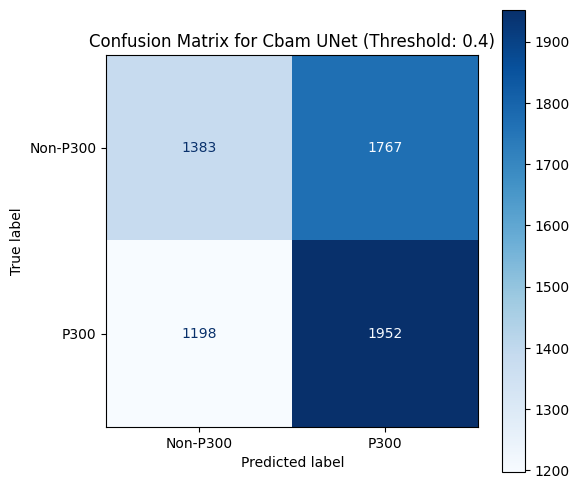

In [149]:
from sklearn.metrics import classification_report

# Apply learned threshold on TEST set
y_test_pred = (probs_test >= 0.4).astype(int)

print("\n--- FINAL TEST SET PERFORMANCE ---")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    y_test_true,
    y_test_pred,
    "Cbam UNet",
    title_suffix=f" (Threshold: {0.4})"
)

Available metrics in history: ['auc', 'loss', 'precision_nonp300', 'precision_p300', 'recall_nonp300', 'recall_p300', 'val_auc', 'val_loss', 'val_precision_nonp300', 'val_precision_p300', 'val_recall_nonp300', 'val_recall_p300']


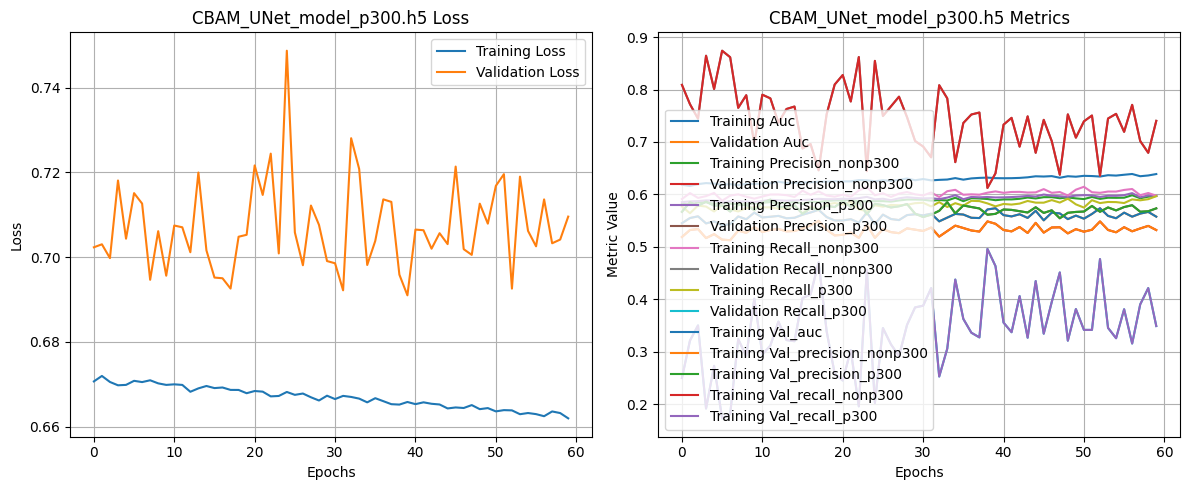

In [150]:
plot_training_history(history, "CBAM_UNet_model_p300.h5")

In [151]:
def eeg_mbconv(x, filters, expand=4, stride=1):
    in_ch = x.shape[-1]
    exp_ch = in_ch * expand

    # Expansion
    if expand != 1:
        x1 = Conv2D(exp_ch, (1,1), padding='same', use_bias=False)(x)
        x1 = BatchNormalization()(x1)
        x1 = Activation('swish')(x1)
    else:
        x1 = x

    # Depthwise temporal conv
    x1 = DepthwiseConv2D(
        kernel_size=(3,1),
        strides=(stride,1),
        padding='same',
        use_bias=False
    )(x1)
    x1 = BatchNormalization()(x1)
    x1 = Activation('swish')(x1)

    # Projection
    x1 = Conv2D(filters, (1,1), padding='same', use_bias=False)(x1)
    x1 = BatchNormalization()(x1)

    # Skip
    if stride == 1 and in_ch == filters:
        x1 = Add()([x, x1])

    return x1


In [152]:
def build_eeg_efficientnet_cbam(input_shape, num_classes=2):
    inp = Input(shape=input_shape)

    # Stem
    x = Conv2D(32, (5,1), padding='same', activation='swish')(inp)
    x = BatchNormalization()(x)

    # -------- Stage 1 --------
    x = eeg_mbconv(x, 32, expand=1)
    x = cbam_block(x)

    # -------- Stage 2 --------
    x = eeg_mbconv(x, 64, expand=4, stride=2)
    x = eeg_mbconv(x, 64, expand=4)
    x = cbam_block(x)

    # -------- Stage 3 --------
    x = eeg_mbconv(x, 128, expand=6, stride=2)
    x = eeg_mbconv(x, 128, expand=6)
    x = cbam_block(x)

    # -------- Stage 4 --------
    x = eeg_mbconv(x, 192, expand=6, stride=2)
    x = eeg_mbconv(x, 192, expand=6)
    x = cbam_block(x)

    # -------- Head --------
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)

    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300')
        ]
    )

    return model

In [154]:
P300_ckpnt = P300MacroF1Checkpoint(
    X_val_final,
    y_val_cat,
    "CBAM_EfficientNet_model_p300.h5"
    )
history = model.fit(
    X_train_final, y_train_cat,
    validation_data=(X_val_final, y_val_cat),
    epochs=60,
    batch_size=16,
    callbacks=[P300_ckpnt],
    verbose=1,
    shuffle=True
)
print("Training complete! Best model saved as CBAM_EfficientNet_model_p300.h5")

Epoch 1/60
1833/1838 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.6403 - loss: 0.6614 - precision_nonp300: 0.5955 - precision_p300: 0.6055 - recall_nonp300: 0.6099 - recall_p300: 0.5907  Saved best model — F1_macro: 0.4942 | F1_P300: 0.6302 | F1_NonP300: 0.3582
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - auc: 0.6403 - loss: 0.6614 - precision_nonp300: 0.5955 - precision_p300: 0.6055 - recall_nonp300: 0.6099 - recall_p300: 0.5907 - val_auc: 0.5499 - val_loss: 0.7262 - val_precision_nonp300: 0.5252 - val_precision_p300: 0.5776 - val_recall_nonp300: 0.7927 - val_recall_p300: 0.2835
Epoch 2/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - auc: 0.6367 - loss: 0.6623 - precision_nonp300: 0.5962 - precision_p300: 0.5999 - recall_nonp300: 0.6230 - recall_p300: 0.5724 - val_auc: 0.5648 - val_loss: 0.7083 - val_precision_nonp300: 0.5404 - val_precision_p300: 0.5662 - val_recall_nonp300: 0.6714 - val_recall_p300: 0.4289
Epoch 3/60
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - auc: 0.6334 - loss: 0

In [155]:
# =========================
# Predict probabilities
# =========================

# Validation set (for threshold tuning)
probs_val = model.predict(X_val_final, verbose=0)[:, 1]
y_val_true = np.argmax(y_val_cat, axis=1)

# Test set (for final evaluation ONLY)
probs_test = model.predict(X_test_final, verbose=0)[:, 1]
y_test_true = y_test.astype(int)

In [156]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, probs_val)

In [157]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_val_true,
    probs_val
)

# thresholds has length = len(precision) - 1
precision = precision[:-1]
recall = recall[:-1]

f1 = 2 * precision * recall / (precision + recall + 1e-8)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (VAL): {best_threshold:.4f}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall:    {recall[best_idx]:.4f}")
print(f"F1-score:  {f1[best_idx]:.4f}")

Best Threshold (VAL): 0.0198
Precision: 0.5001
Recall:    1.0000
F1-score:  0.6667



--- FINAL TEST SET PERFORMANCE ---
              precision    recall  f1-score   support

    Non-P300       0.53      0.35      0.42      3150
        P300       0.52      0.70      0.59      3150

    accuracy                           0.52      6300
   macro avg       0.53      0.52      0.51      6300
weighted avg       0.53      0.52      0.51      6300



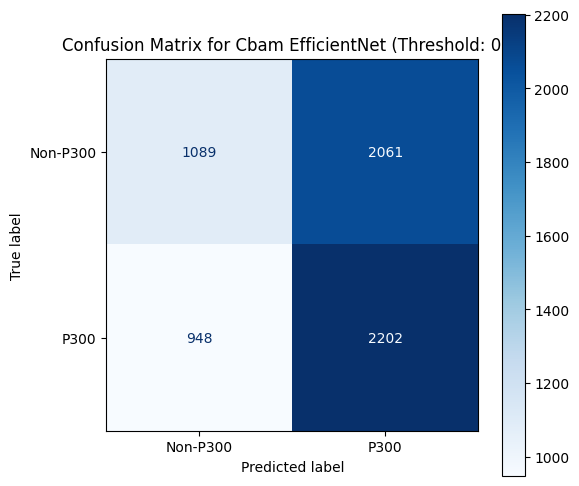

In [163]:
from sklearn.metrics import classification_report

# Apply learned threshold on TEST set
y_test_pred = (probs_test >= 0.4).astype(int)

print("\n--- FINAL TEST SET PERFORMANCE ---")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    y_test_true,
    y_test_pred,
    "Cbam EfficientNet",
    title_suffix=f" (Threshold: {0.4})"
)

Available metrics in history: ['auc', 'loss', 'precision_nonp300', 'precision_p300', 'recall_nonp300', 'recall_p300', 'val_auc', 'val_loss', 'val_precision_nonp300', 'val_precision_p300', 'val_recall_nonp300', 'val_recall_p300']


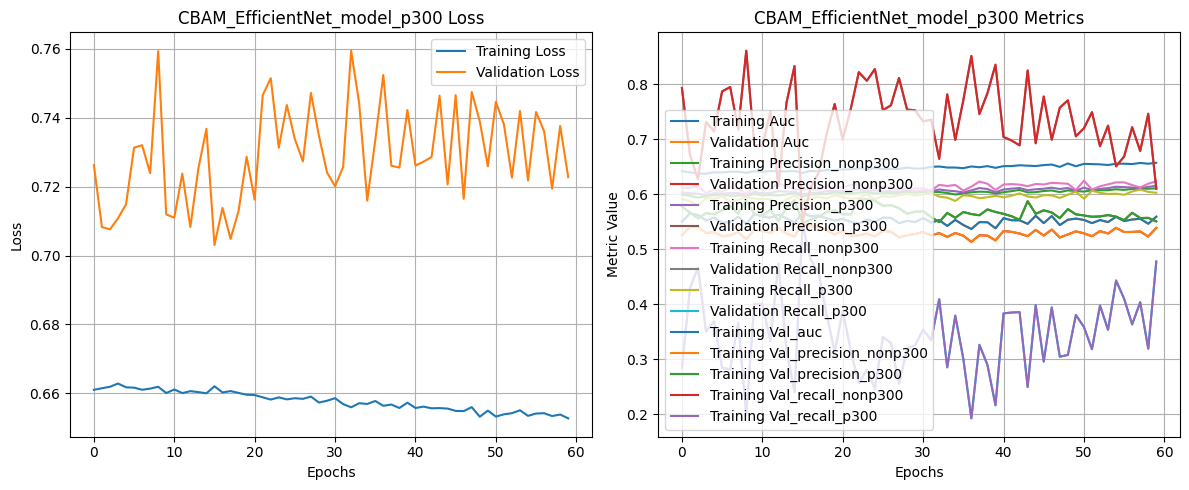

In [164]:
plot_training_history(history, "CBAM_EfficientNet_model_p300")